# Forecasting Spare Parts Inventory

## Data Science Project

**Client:** NewX Services  
**Project Reference:** PM-PR-0027  
**Project Category:** Forecasting Spare Parts Inventory

##  Project Overview

This project focuses on forecasting spare parts demand for service centres of NewX Services. Effective inventory management is a major challenge because service centres need to maintain sufficient spare parts availability while controlling inventory holding costs.

The objective of this project is to develop a predictive forecasting model using historical service data. The forecasted demand can help service centres plan spare parts inventory according to expected market demand and support Just-in-Time (JIT) inventory standards.

##  Business Case

Inventory management is an important challenge for service centres. Maintaining excess spare parts inventory increases inventory holding costs, while insufficient inventory can result in spare parts availability problems.

Therefore, accurate demand forecasting is required to estimate future spare parts requirements. A forecasting model can help service centres maintain an appropriate inventory level based on expected demand.

##  Project Goal

The primary goal of this project is to create a predictive model for inventory forecasting so that service centres can achieve Just-in-Time (JIT) inventory standards.

The forecasting solution aims to improve spare parts availability while reducing unnecessary inventory holding costs.

## Project Objectives

The main objectives of this project are:

1. To understand the historical service data.
2. To clean and preprocess the dataset.
3. To analyse spare parts demand patterns.
4. To aggregate spare parts demand into a suitable time-series format.
5. To identify trends and seasonal patterns.
6. To develop ARIMA and SARIMAX forecasting models.
7. To perform SARIMAX hyperparameter tuning.
8. To evaluate the forecasting models using suitable performance metrics.
9. To compare ARIMA and SARIMAX models.
10. To select the best-performing forecasting model.
11. To generate future spare parts demand forecasts.
12. To support inventory planning and JIT inventory management.

##  Project Workflow

The project follows the below workflow:

**Business Problem**  
↓  
**Data Collection**  
↓  
**Data Understanding**  
↓  
**Data Cleaning & Preprocessing**  
↓  
**Exploratory Data Analysis**  
↓  
**Spare Parts Demand Aggregation**  
↓  
**Time-Series Preparation**  
↓  
**Train-Test Split**  
↓  
**ARIMA Modelling**  
↓  
**SARIMAX Modelling**  
↓  
**Hyperparameter Tuning**  
↓  
**Model Evaluation**  
↓  
**ARIMA vs SARIMAX Comparison**  
↓  
**Best Model Selection**  
↓  
**Full Data Refit**  
↓  
**14-Week Future Forecast**  
↓  
**Forecast Visualization**  
↓  
**Business Interpretation**

#  Import Required Libraries and Dependencies

In [8]:
# import required dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['font.size'] = 15
plt.rcParams['figure.figsize'] = (10, 6)
import seaborn as sns
pd.set_option('display.max_columns',None)
import os
import itertools
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from statsmodels.tools.eval_measures import rmse
from pandas.tseries.offsets import DateOffset
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)

In [9]:
!pip install pymysql
!pip install mysql-connector

##  Connect to MySQL Database and Load Service Data

In [10]:
import pandas as pd
import mysql.connector

connection = mysql.connector.connect(
    host="18.136.157.135",
    port=3306,
    user="dm_usdata_sql",
    password="37z<49REb&mKnl4AV!vJ",
    database="project_service_data"
)

print("Connected successfully!")

df = pd.read_sql_query(
    "SELECT * FROM service_data",
    connection
)

print("Shape:", df.shape)
print(df.head())

connection.close()

Connected successfully!
Shape: (28482, 7)
  invoice_date job_card_date business_partner_name  vehicle_no  \
0     30-05-17      30-05-17        shivXXXXXXXXXX  KA03MFXXXX   
1     02-06-17      31-05-17        KIRAXXXXXXXXXX  KA53ESXXXX   
2     02-06-17      31-05-17        KIRAXXXXXXXXXX  KA53ESXXXX   
3     02-06-17      31-05-17        KIRAXXXXXXXXXX  KA53ESXXXX   
4     02-06-17      31-05-17        KIRAXXXXXXXXXX  KA53ESXXXX   

              vehicle_model current_km_reading invoice_line_text  
0  BAJAJ AVENGER STREET 220              50000        ENGINE OIL  
1       BAJAJ PULSAR NS 200                758        ENGINE OIL  
2       BAJAJ PULSAR NS 200                758            POLISH  
3       BAJAJ PULSAR NS 200                758       CONSUMABLES  
4       BAJAJ PULSAR NS 200                758       COOLANT OIL  


In [11]:
df.head()

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
0,30-05-17,30-05-17,shivXXXXXXXXXX,KA03MFXXXX,BAJAJ AVENGER STREET 220,50000,ENGINE OIL
1,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,ENGINE OIL
2,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,POLISH
3,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,CONSUMABLES
4,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,COOLANT OIL


In [12]:
print('Shape of the DataFrame:',df.shape)

Shape of the DataFrame: (28482, 7)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28482 entries, 0 to 28481
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   invoice_date           28482 non-null  object
 1   job_card_date          28482 non-null  object
 2   business_partner_name  28482 non-null  object
 3   vehicle_no             28482 non-null  object
 4   vehicle_model          28482 non-null  object
 5   current_km_reading     28482 non-null  object
 6   invoice_line_text      28476 non-null  object
dtypes: object(7)
memory usage: 1.5+ MB


In [14]:
df.describe()

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
count,28482,28482,28482,28482,28482,28482,28476
unique,555,553,1010,846,28,3474,503
top,01-12-18,01-12-18,venkXXXXXXXXXX,KA53EVXXXX,BAJAJ PULSAR 150,0,ENGINE OIL
freq,179,179,424,1313,8633,842,3802


In [15]:
df.describe(include='O')

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
count,28482,28482,28482,28482,28482,28482,28476
unique,555,553,1010,846,28,3474,503
top,01-12-18,01-12-18,venkXXXXXXXXXX,KA53EVXXXX,BAJAJ PULSAR 150,0,ENGINE OIL
freq,179,179,424,1313,8633,842,3802


In [16]:
print('Datatype of Each Column: \n',df.dtypes)

Datatype of Each Column: 
 invoice_date             object
job_card_date            object
business_partner_name    object
vehicle_no               object
vehicle_model            object
current_km_reading       object
invoice_line_text        object
dtype: object


In [17]:
print('Duplicated Values: ',df.duplicated().sum())

Duplicated Values:  383


In [18]:
df[df.duplicated(keep=False)]

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
24,03-06-17,31-05-17,MAYAXXXXXXXXXX,KA05JGXXXX,BAJAJ PULSAR 220,25000,DISC PAD
40,03-06-17,31-05-17,MAYAXXXXXXXXXX,KA05JGXXXX,BAJAJ PULSAR 220,25000,DISC PAD
41,05-06-17,01-06-17,srivXXXXXXXXXX,KA02EWXXXX,BAJAJ PULSAR 150,41458,BRAKE ADJUSTMENT
43,05-06-17,01-06-17,srivXXXXXXXXXX,KA02EWXXXX,BAJAJ PULSAR 150,41458,BRAKE ADJUSTMENT
577,13-06-17,13-06-17,subhXXXXXXXXXX,KA53J9XXXX,BAJAJ AVENGER STREET 220,14484,SILENCER
...,...,...,...,...,...,...,...
28318,04-01-19,04-01-19,ALOKXXXXXXXXXX,KA53EWXXXX,BAJAJ CT 100,27786,BRAKE SHOE
28343,04-01-19,04-01-19,yeshXXXXXXXXXX,KA40ECXXXX,BAJAJ PULSAR 220,11541,DISC PAD
28346,04-01-19,04-01-19,yeshXXXXXXXXXX,KA40ECXXXX,BAJAJ PULSAR 220,11541,DISC PAD
28444,05-01-19,05-01-19,ashoXXXXXXXXXX,KA53EPXXXX,BAJAJ PULSAR 150,22413,BRAKE SHOE


In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.duplicated().sum()

np.int64(0)

# Missing Values

In [21]:
df.isnull().sum()

invoice_date             0
job_card_date            0
business_partner_name    0
vehicle_no               0
vehicle_model            0
current_km_reading       0
invoice_line_text        5
dtype: int64

In [22]:
# Pecentage of Missing Values for Each Column :
features_with_na=[features for features in df.columns if df[features].isnull().sum()>0]
print('The Features that have missing values are as follows: \n',features_with_na)
print('-'*125)
for feature in features_with_na:
    print('Percentage of missing values in {} Feature is {} %'.format(feature, np.round(df[feature].isnull().mean()*100, 2)))

The Features that have missing values are as follows: 
 ['invoice_line_text']
-----------------------------------------------------------------------------------------------------------------------------
Percentage of missing values in invoice_line_text Feature is 0.02 %


In [23]:
df.dropna(inplace=True)

In [24]:
df.isnull().sum().sum()

np.int64(0)

 ##  DateTime  Preprocessing

In [25]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'],dayfirst=True)
df['job_card_date'] = pd.to_datetime(df['job_card_date'],dayfirst=True)

In [26]:
df.head(3)

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
0,2017-05-30,2017-05-30,shivXXXXXXXXXX,KA03MFXXXX,BAJAJ AVENGER STREET 220,50000,ENGINE OIL
1,2017-06-02,2017-05-31,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,ENGINE OIL
2,2017-06-02,2017-05-31,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,POLISH


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28094 entries, 0 to 28481
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   invoice_date           28094 non-null  datetime64[ns]
 1   job_card_date          28094 non-null  datetime64[ns]
 2   business_partner_name  28094 non-null  object        
 3   vehicle_no             28094 non-null  object        
 4   vehicle_model          28094 non-null  object        
 5   current_km_reading     28094 non-null  object        
 6   invoice_line_text      28094 non-null  object        
dtypes: datetime64[ns](2), object(5)
memory usage: 1.7+ MB


In [28]:
print(df.invoice_date.min())
print(df.invoice_date.max())

2017-05-30 00:00:00
2019-01-06 00:00:00


In [29]:
print(df.job_card_date.min())
print(df.job_card_date.max())

2017-05-30 00:00:00
2019-01-06 00:00:00


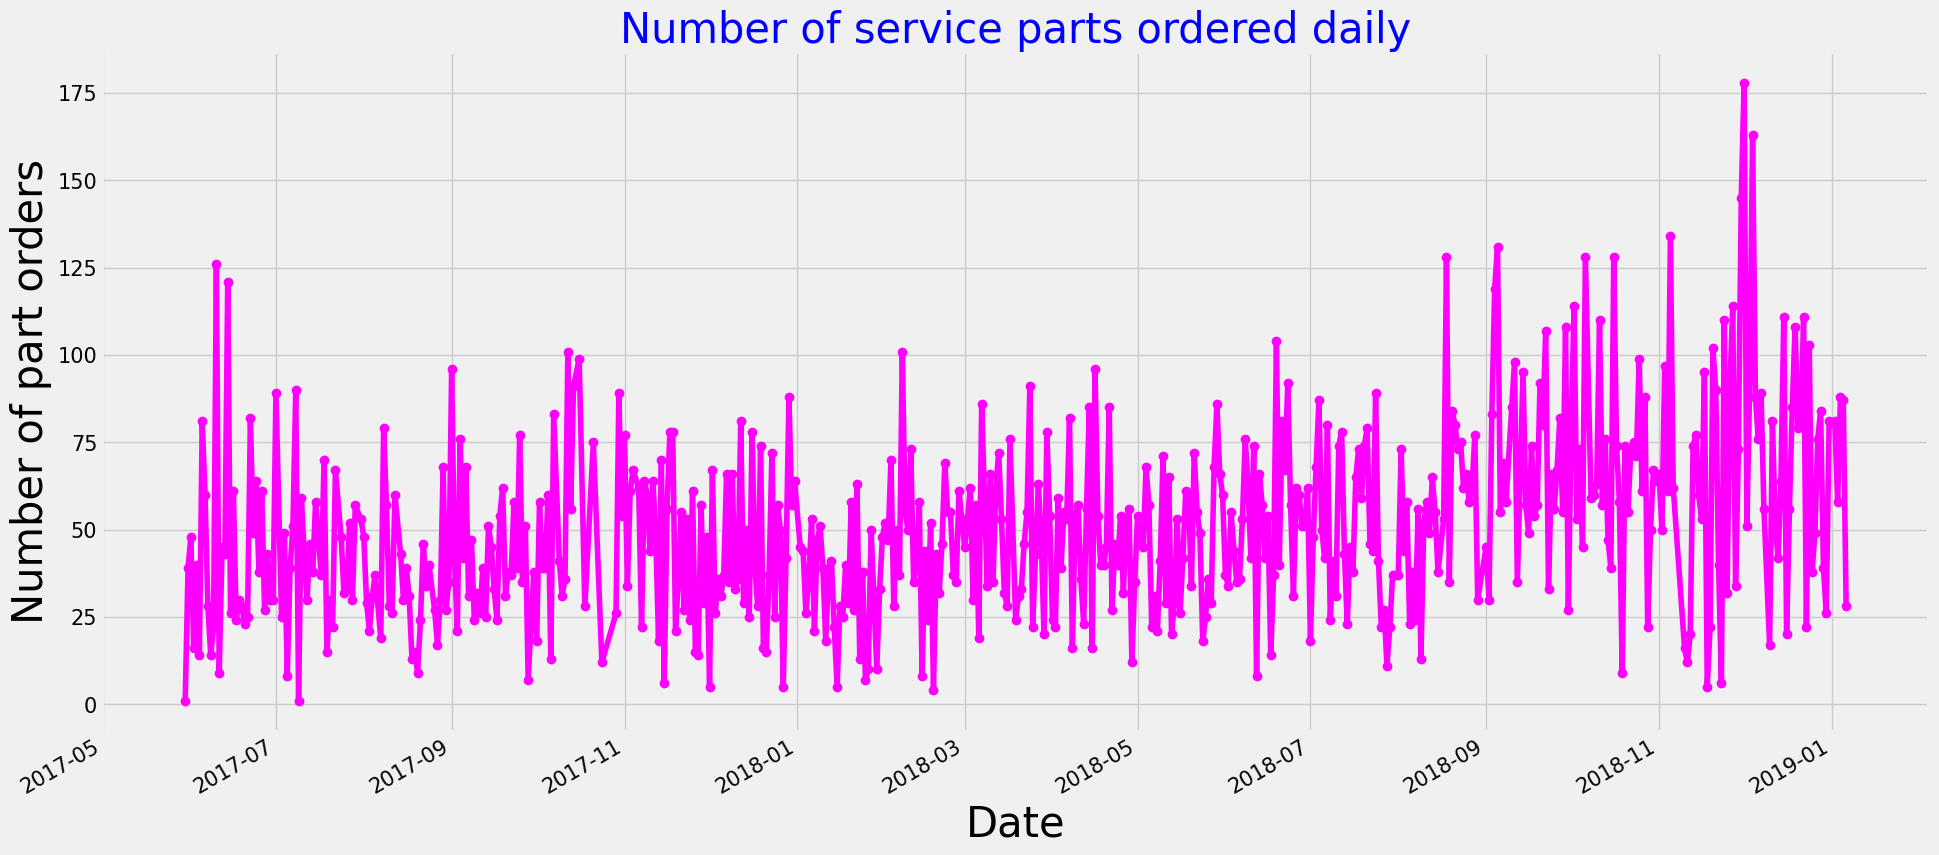

In [30]:
df.groupby('job_card_date')['job_card_date'].count().plot(figsize=(21,10),color='magenta',marker='o')
plt.title("Number of service parts ordered daily",fontsize=30,color='blue')
plt.ylabel("Number of part orders",fontsize=30)
plt.xlabel("Date",fontsize=30);

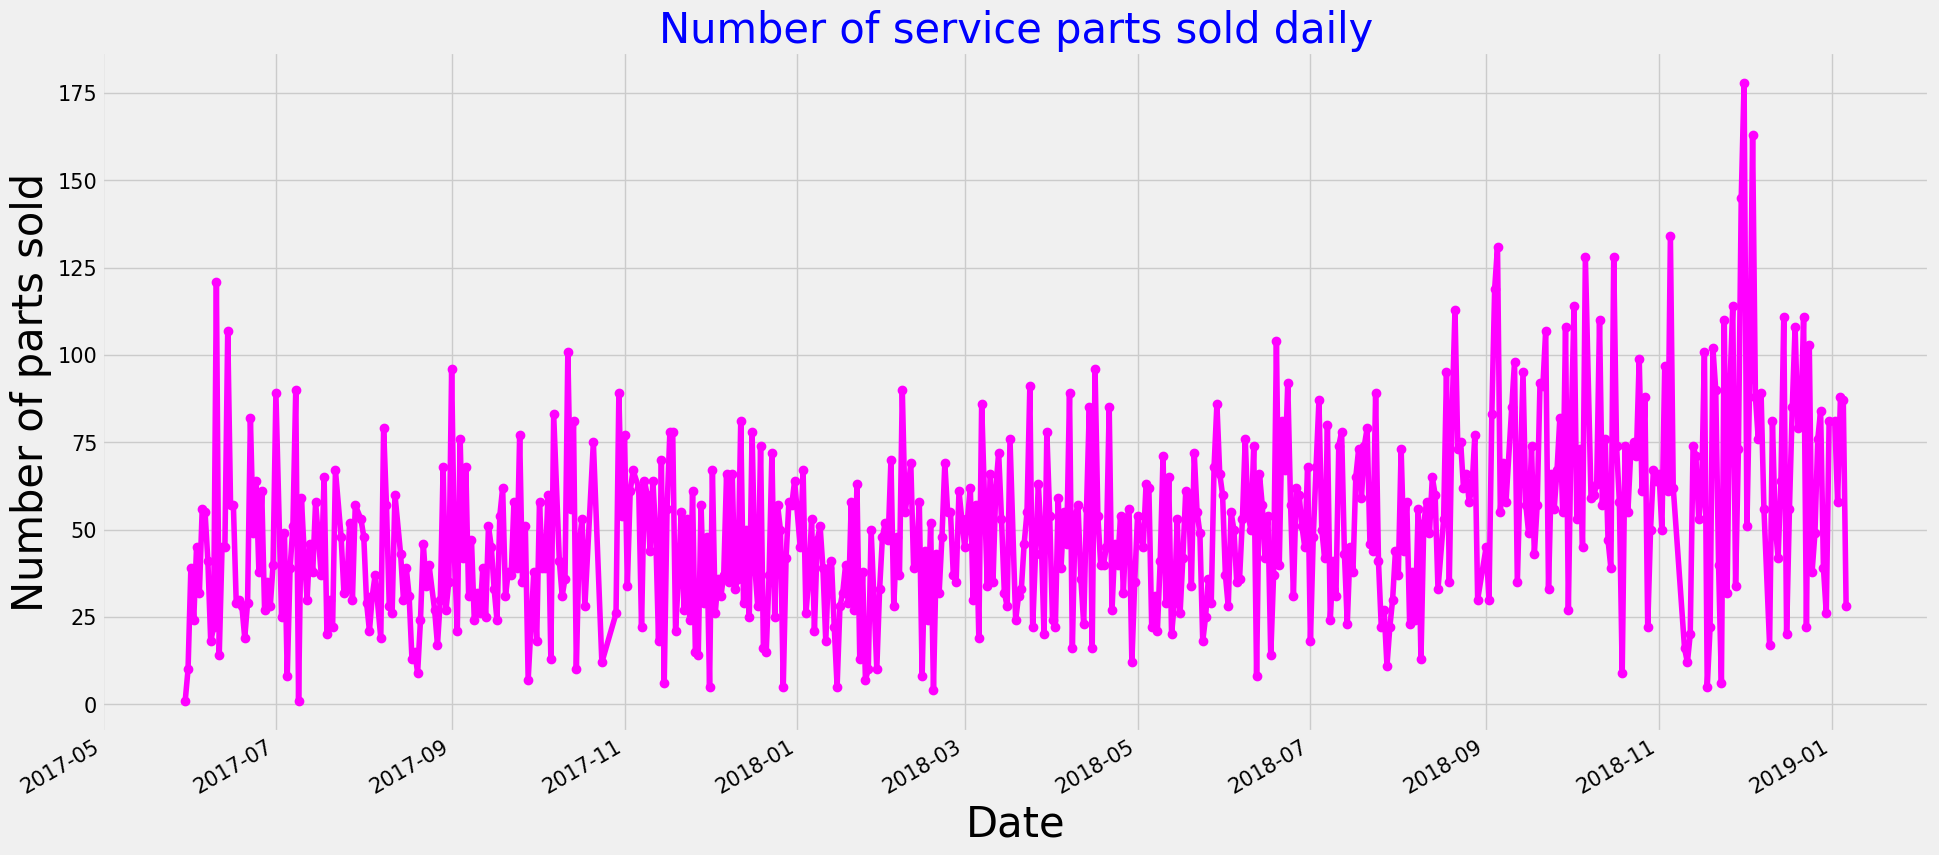

In [31]:
df.groupby('invoice_date')['invoice_date'].count().plot(figsize=(21,10),color='magenta',marker='o')
plt.title("Number of service parts sold daily",fontsize=30,color='blue')
plt.ylabel("Number of parts sold",fontsize=30)
plt.xlabel("Date",fontsize=30);

### Categorical Features

In [32]:
cat_fe = [feature for feature in df.columns if df[feature].dtype == 'O']
cat_fe

['business_partner_name',
 'vehicle_no',
 'vehicle_model',
 'current_km_reading',
 'invoice_line_text']

### Number of Unique Categories in each Feature

In [33]:
for feature in cat_fe:
    print('The no. of unique categories in {} feature is : {}'.format(feature,df[feature].nunique()))

The no. of unique categories in business_partner_name feature is : 1010
The no. of unique categories in vehicle_no feature is : 846
The no. of unique categories in vehicle_model feature is : 28
The no. of unique categories in current_km_reading feature is : 3474
The no. of unique categories in invoice_line_text feature is : 503


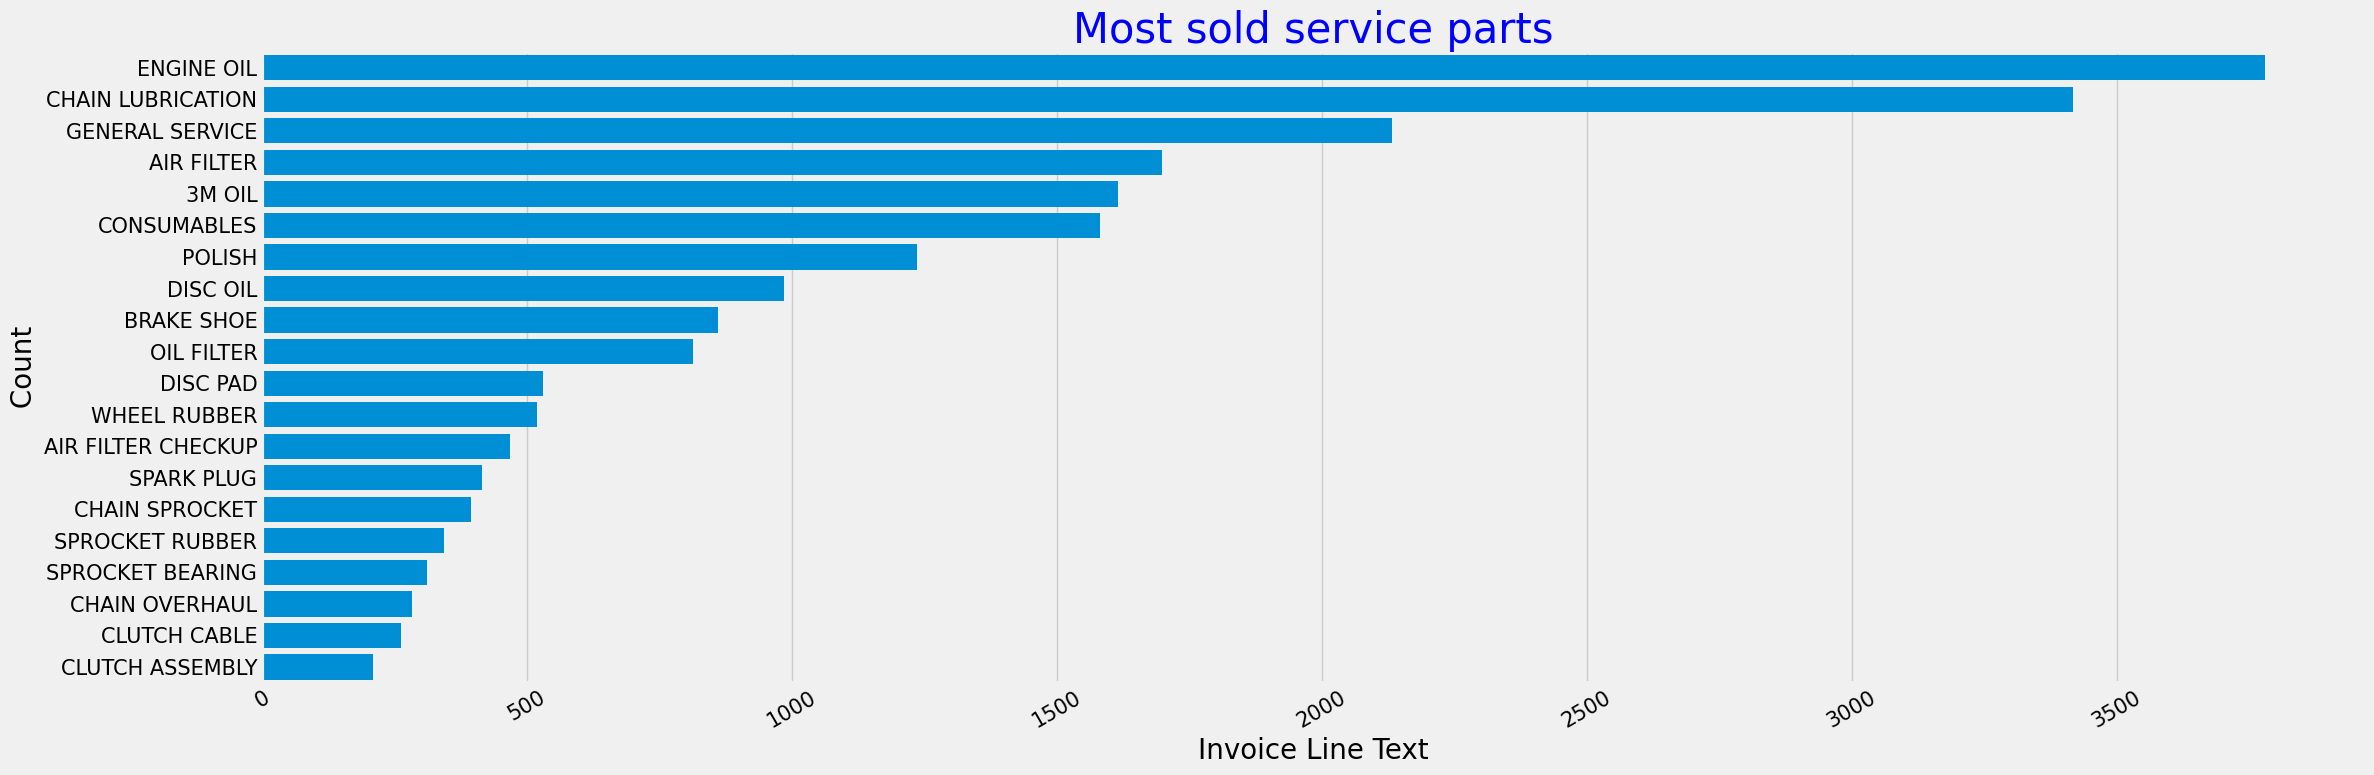

In [34]:
plt.figure(figsize=(24,8))
sns.countplot(df['invoice_line_text'],order=df['invoice_line_text'].value_counts().index[:20],saturation=10)
plt.xticks(rotation=30)
plt.xlabel("Invoice Line Text",fontsize=20)
plt.ylabel(" Count ",fontsize=20)
plt.title("Most sold service parts",fontsize=30,color='blue')
plt.tight_layout();

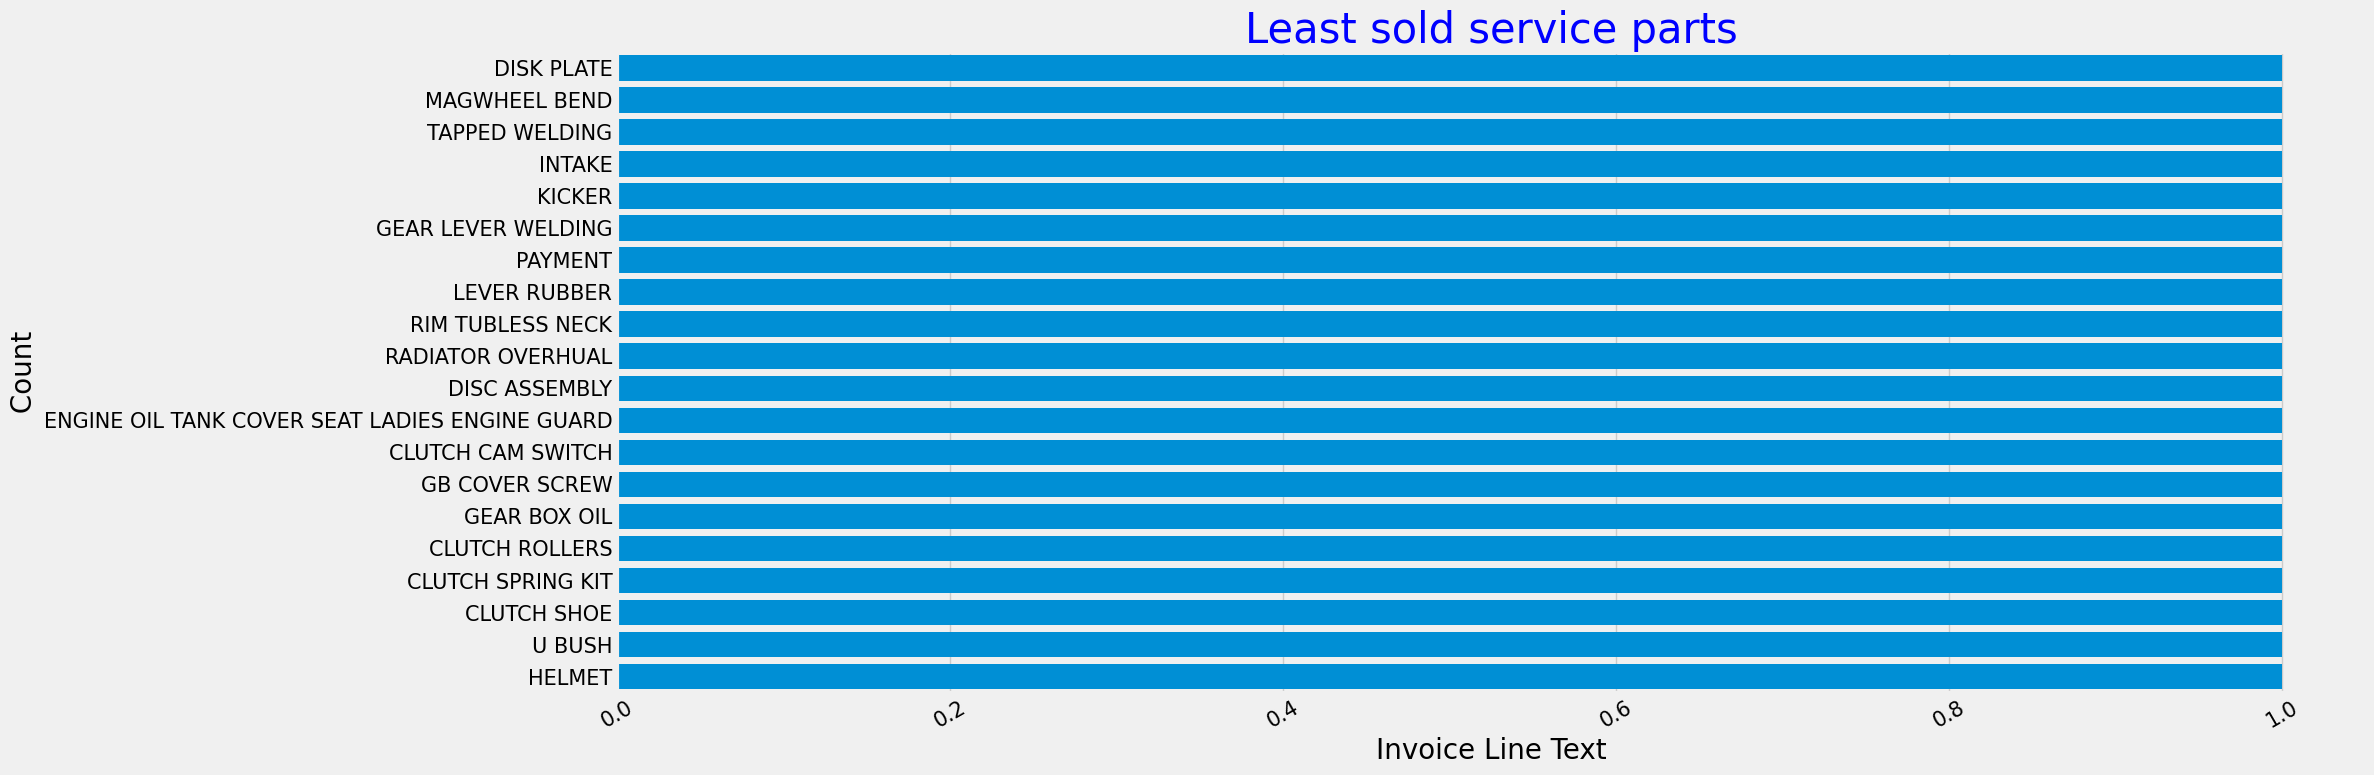

In [35]:
plt.figure(figsize=(24,8))
sns.countplot(df['invoice_line_text'],order=df['invoice_line_text'].value_counts().index[-20:],saturation=10)
plt.xticks(rotation=30)
plt.xlabel("Invoice Line Text",fontsize=20)
plt.ylabel(" Count ",fontsize=20)
plt.title("Least sold service parts",fontsize=30,color='blue')
plt.tight_layout();


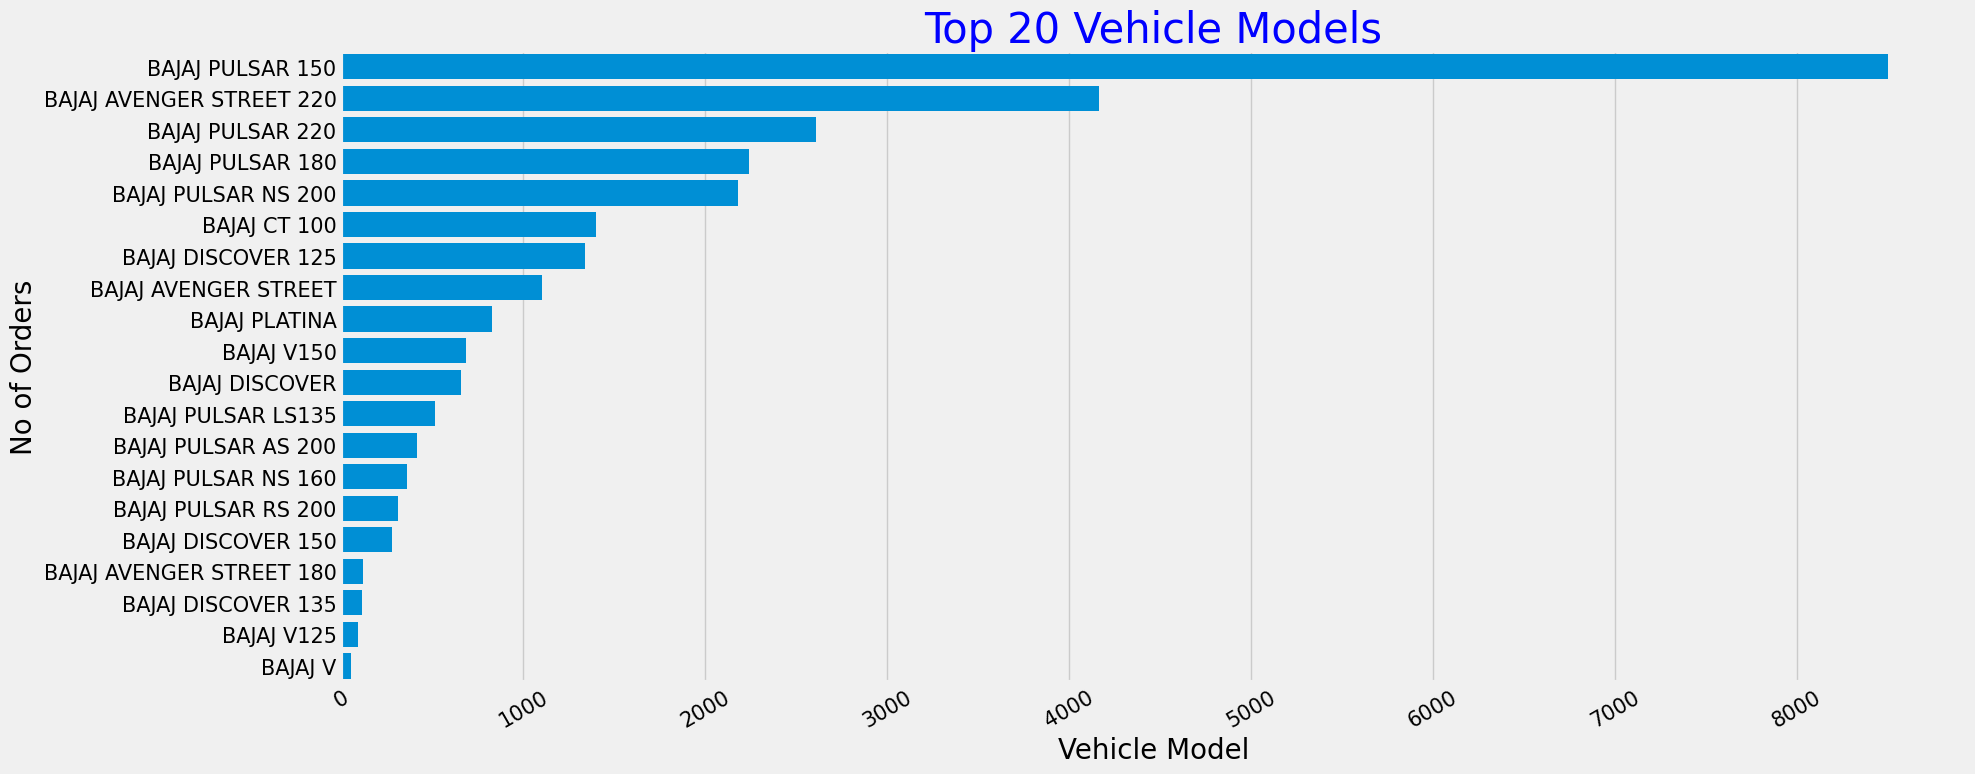

In [36]:
plt.figure(figsize=(20,8))
sns.countplot(df['vehicle_model'],order=df['vehicle_model'].value_counts().iloc[:20].index,saturation=10)
plt.xlabel("Vehicle Model",fontsize=20)
plt.ylabel("No of Orders",fontsize=20)
plt.xticks(rotation=30)
plt.title("Top 20 Vehicle Models",fontsize=30,color='blue')
plt.tight_layout();

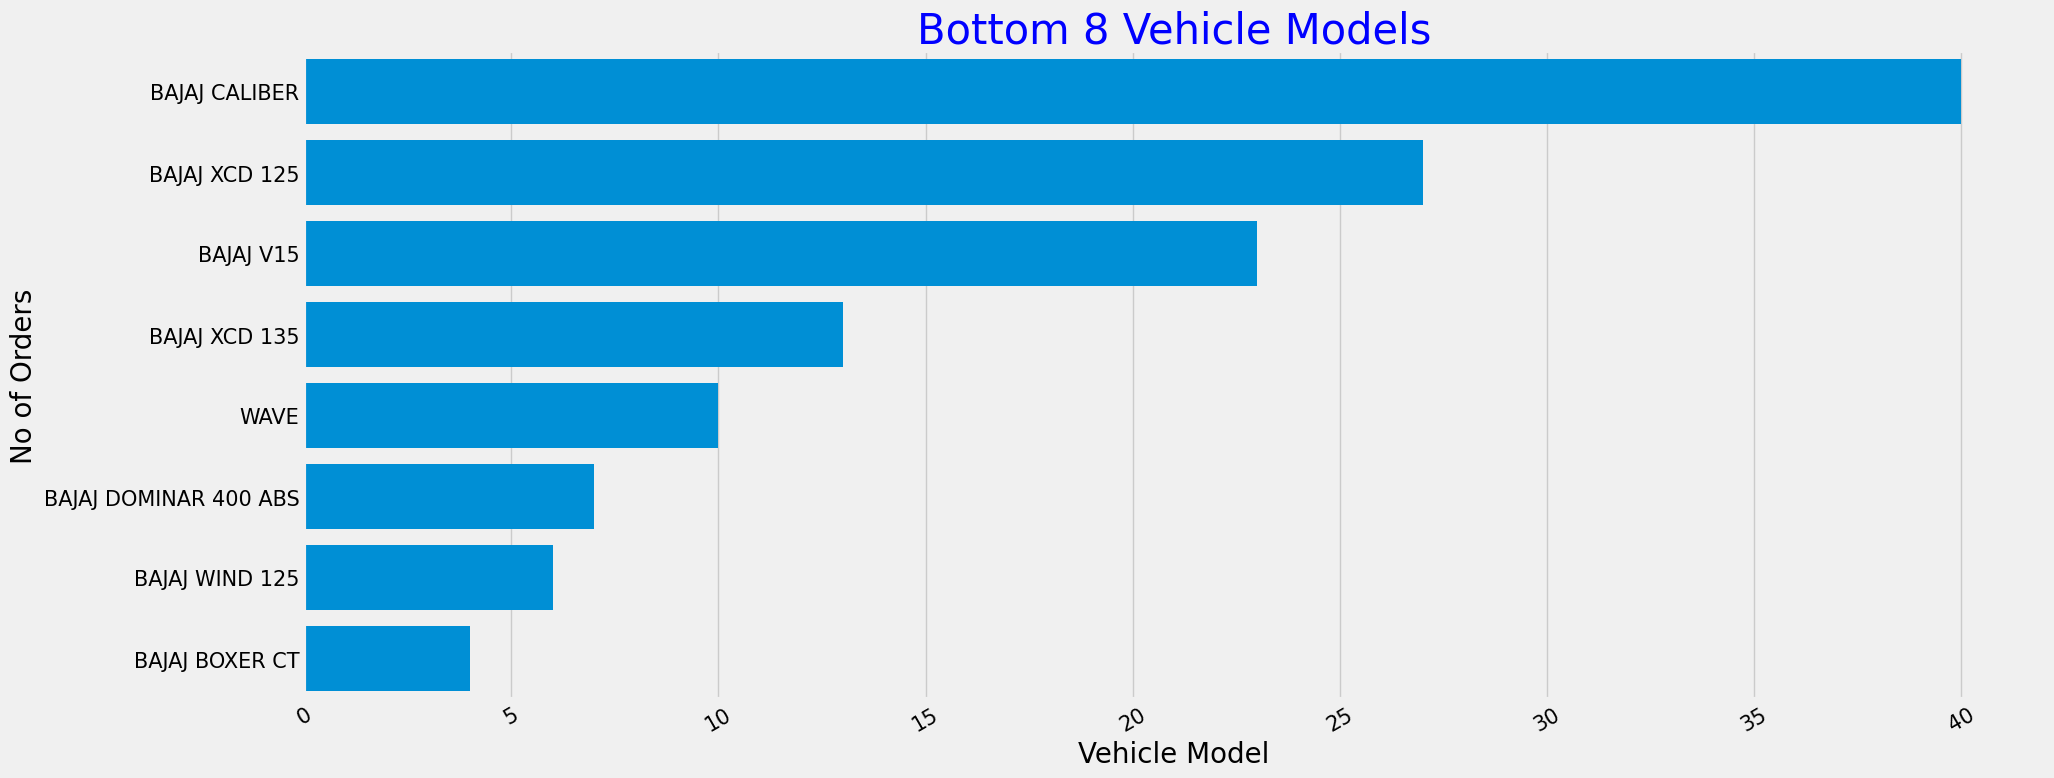

In [37]:
plt.figure(figsize=(20,8))
sns.countplot(df['vehicle_model'],order=df['vehicle_model'].value_counts().iloc[-8:].index,saturation=10)
plt.xlabel("Vehicle Model",fontsize=20)
plt.ylabel("No of Orders",fontsize=20)
plt.xticks(rotation=30)
plt.title("Bottom 8 Vehicle Models",fontsize=30,color='blue');

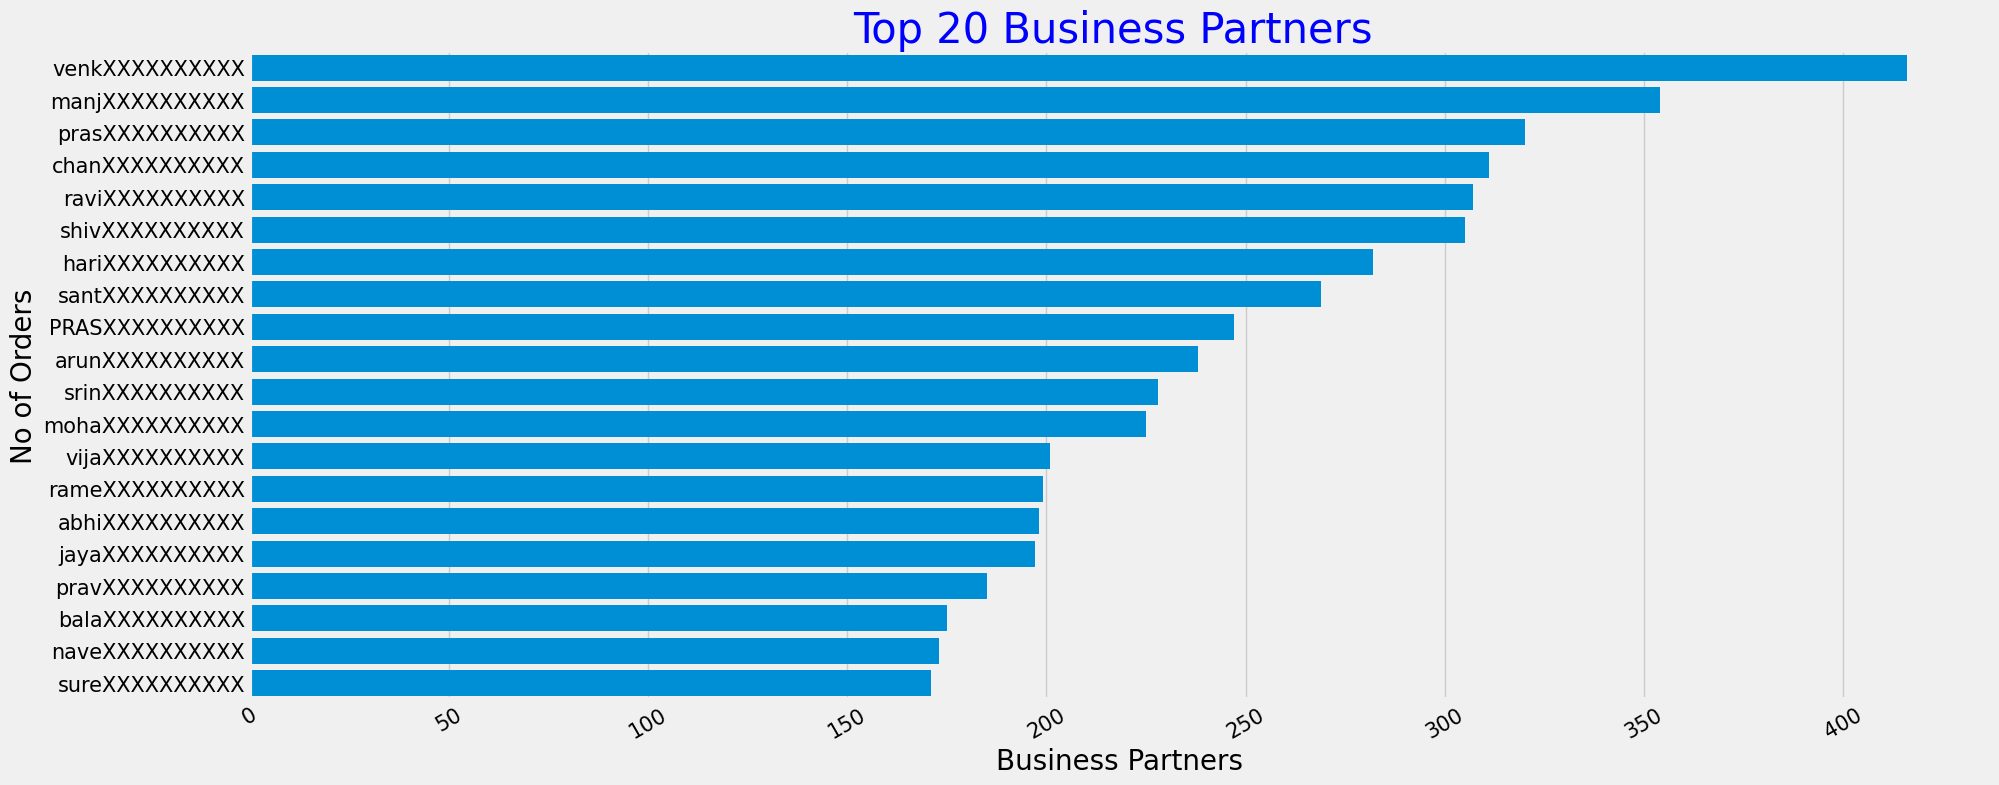

In [38]:
plt.figure(figsize=(20,8))
sns.countplot(df['business_partner_name'],order=df['business_partner_name'].value_counts().iloc[:20].index,saturation=10)
plt.xlabel("Business Partners",fontsize=20)
plt.ylabel("No of Orders",fontsize=20)
plt.xticks(rotation=30)
plt.title("Top 20 Business Partners ",fontsize=30,color='blue');

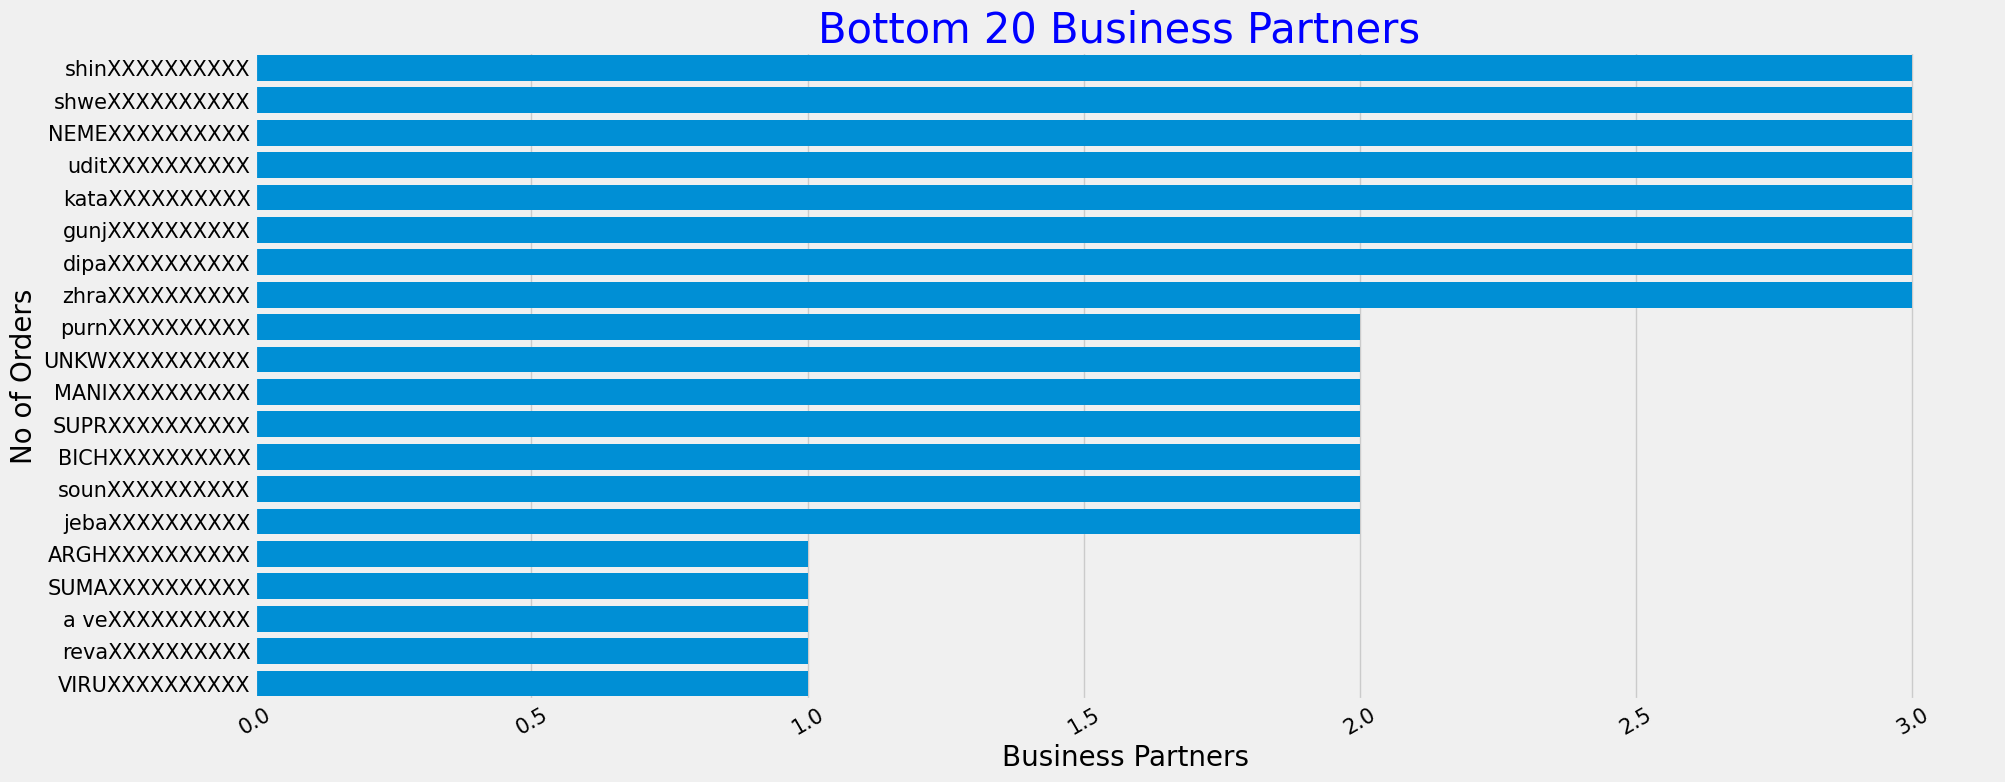

In [39]:
plt.figure(figsize=(20,8))
sns.countplot(df['business_partner_name'],order=df['business_partner_name'].value_counts().iloc[-20:].index,saturation=10)
plt.xlabel("Business Partners",fontsize=20)
plt.ylabel('No of Orders',fontsize=20)
plt.xticks(rotation=30)
plt.title("Bottom 20 Business Partners ",fontsize=30,color='blue');

###  Numerical Data Analysis

In [40]:
num_fe = ['current_km_reading']

In [41]:
df.current_km_reading.describe()

count     28094
unique     3474
top           0
freq        824
Name: current_km_reading, dtype: object

<Axes: xlabel='current_km_reading', ylabel='Count'>

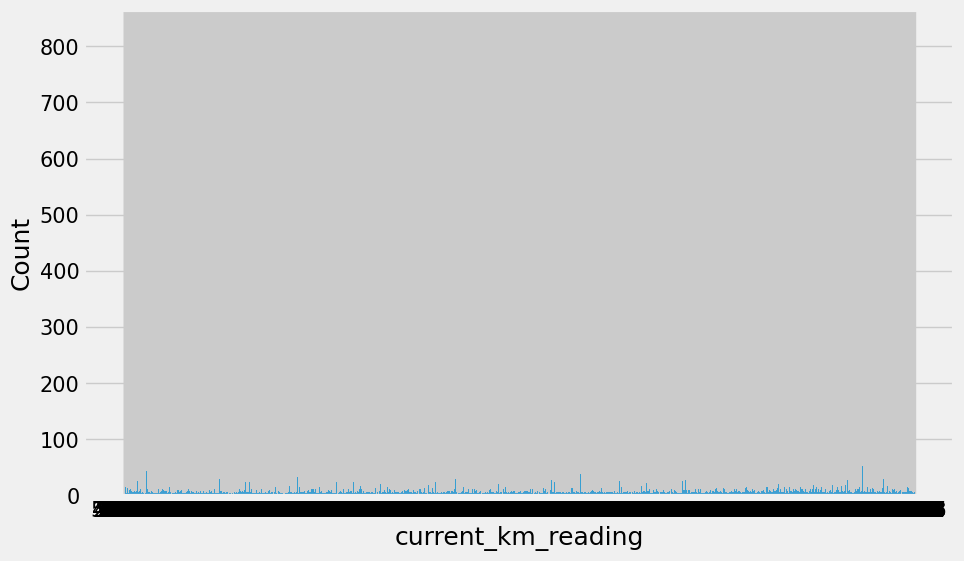

In [42]:
sns.histplot(df.current_km_reading)

## Target Variable

In [43]:
pd.set_option('display.max_rows',None)

In [44]:
df['invoice_line_text'].value_counts()

invoice_line_text
ENGINE OIL                                        3780
CHAIN LUBRICATION                                 3417
GENERAL SERVICE                                   2132
AIR FILTER                                        1698
3M OIL                                            1615
CONSUMABLES                                       1582
POLISH                                            1236
DISC OIL                                           985
BRAKE SHOE                                         861
OIL FILTER                                         814
DISC PAD                                           530
WHEEL RUBBER                                       518
AIR FILTER CHECKUP                                 467
SPARK PLUG                                         414
CHAIN SPROCKET                                     394
SPROCKET RUBBER                                    344
SPROCKET BEARING                                   311
CHAIN OVERHAUL                                 

In [45]:
pd.reset_option('display.max_rows')

In [46]:
labels_to_delete = ['CHARGE', 'INSURANCE', 'PAYMENT', 'REGISTER', 'ADJUSTMENT', 'NUMBER PLATE','PACKING',
                    'REMOVAL', 'THREADING', 'CLEANING', 'FEES', 'REBORE', 'PUNCHER', 'EX SHOW ROOM', 'CRANK RESET',
                    'DENT', 'RC CARD', 'TAX', 'ENGINE WORK','SERVICE', 'CHECK', 'LABOUR', 'POLISH','TOP UP','TOPUP',
                    'LOGO','HAND GLOUSE', 'NO PLATE', 'WELDING','WIELDING','WASHING','OVERHUAL','OVERHAUL','STICKER',
                    'ENGINE RE CONDITION','STAY']

In [47]:
df1=df.copy()

for index, text in df1['invoice_line_text'].items():
    if text == 'SERVICE AND ONE WAY CLUTCH BUSH KIT':
        print('Changed the text from "SERVICE AND ONE WAY CLUTCH BUSH KIT" to "ONE WAY CLUTCH BUSH KIT"')
        df1.loc[index, 'invoice_line_text'] = 'ONE WAY CLUTCH BUSH KIT'

    if text == 'tyre':
        print('Changed the text from "tyre" to "TYRE"')
        df1.loc[index, 'invoice_line_text'] = 'TYRE'

    if text == 'TYRE REPLACEMENT':
        print('Changed the text from "TYRE REPLACEMENT" to "TYRE"')
        df1.loc[index, 'invoice_line_text'] = 'TYRE'

    if text == 'VISIOR WITH LABOUR':
        print('Changed the text from "VISIOR WITH LABOUR" to "VISIOR"')
        df1.loc[index, 'invoice_line_text'] = 'VISIOR'

    if text.strip() == 'PETROL':
        print('Deleting line that has PETROL only')
        df1.drop(index=index, inplace=True)

    if text == 'clutch cable':
        print('Changed the text from "clutch cable" to "CLUTCH CABLE"')
        df1.loc[index, 'invoice_line_text'] = 'CLUTCH CABLE'

    if text == 'Clutch cable':
        print('Changed the text from "Clutch cable" to "CLUTCH CABLE"')
        df1.loc[index, 'invoice_line_text'] = 'CLUTCH CABLE'

    if text == 'Clutch CABLE':
        print('Changed the text from "Clutch CABLE" to "CLUTCH CABLE"')
        df1.loc[index, 'invoice_line_text'] = 'CLUTCH CABLE'

    if text == 'CLUTCH REPALCEMENT':
        print('Changed the text from "CLUTCH REPALCEMENT" to "CLUTCH"')
        df1.loc[index, 'invoice_line_text'] = 'CLUTCH'

    if text == 'DOOM REPLACEMENT':
        print('Changed the text from "DOOM REPLACEMENT" to "DOOM"')
        df1.loc[index, 'invoice_line_text'] = 'DOOM'

    if text == 'handle weight':
        print('Changed the text from "handle weight" to "HANDLE WEIGHT"')
        df1.loc[index, 'invoice_line_text'] = 'HANDLE WEIGHT'

    if text == 'INTAKE':
        print('Changed the text from "INTAKE" to "AIR INTAKE"')
        df1.loc[index, 'invoice_line_text'] = 'AIR INTAKE'

    if text == 'SPPEDOMETER CABLE':
        print('Changed the text from "SPPEDOMETER CABLE" to "SPPEDOMETER CABLE"')
        df1.loc[index, 'invoice_line_text'] = 'SPPEDOMETER CABLE'

    if text == 'SELF REALY':
        print('Changed the text from "SELF REALY" to "SELF RELAY"')
        df1.loc[index, 'invoice_line_text'] = 'SELF RELAY'

    if text == 'CHAIN LUBRICATION':
        print('Changed the text from "CHAIN LUBRICATION" to "CHAIN LUBRICANT"')
        df1.loc[index, 'invoice_line_text'] = 'CHAIN LUBRICANT'

    for del_label in labels_to_delete:
        if text.upper().find(del_label) != -1:
            print('Deleting line with text : ', text)
            df1.drop(index=index, inplace=True,errors='ignore')

Deleting line with text :  POLISH
Changed the text from "CHAIN LUBRICATION" to "CHAIN LUBRICANT"
Changed the text from "CHAIN LUBRICATION" to "CHAIN LUBRICANT"
Deleting line with text :  GENERAL SERVICE
Changed the text from "CHAIN LUBRICATION" to "CHAIN LUBRICANT"
Deleting line with text :  PACKING KIT
Deleting line with text :  BRAKE ADJUSTMENT
Deleting line with text :  GENERAL SERVICE
Changed the text from "CHAIN LUBRICATION" to "CHAIN LUBRICANT"
Deleting line with text :  AIR FILTER CHECKUP
Deleting line with text :  AIR FILTER CHECKUP
Changed the text from "CHAIN LUBRICATION" to "CHAIN LUBRICANT"
Deleting line with text :  TANK CLEANING
Changed the text from "CHAIN LUBRICATION" to "CHAIN LUBRICANT"
Changed the text from "CHAIN LUBRICATION" to "CHAIN LUBRICANT"
Deleting line with text :  GENERAL SERVICE
Changed the text from "CHAIN LUBRICATION" to "CHAIN LUBRICANT"
Deleting line with text :  AIR FILTER CHECKUP
Deleting line with text :  GENERAL SERVICE
Changed the text from "Clutc

In [48]:
pd.set_option('display.max_rows',None)
df1['invoice_line_text'].value_counts()


invoice_line_text
ENGINE OIL                                        3780
CHAIN LUBRICANT                                   3417
AIR FILTER                                        1698
3M OIL                                            1615
CONSUMABLES                                       1582
DISC OIL                                           985
BRAKE SHOE                                         861
OIL FILTER                                         814
DISC PAD                                           530
WHEEL RUBBER                                       518
SPARK PLUG                                         414
CHAIN SPROCKET                                     394
SPROCKET RUBBER                                    344
CLUTCH CABLE                                       340
SPROCKET BEARING                                   311
CLUTCH ASSEMBLY                                    209
CLUTCH COVER GASKET                                187
TANK COVER                                     

In [49]:
pd.reset_option('display.max_rows')

In [50]:
df1.shape

(22992, 7)

In [51]:
df1.isnull().sum().sum()

np.int64(0)

# EDA

In [52]:
df2 = df1[['job_card_date','invoice_line_text']]
df2

,job_card_date,invoice_line_text
0,2017-05-30,ENGINE OIL
1,2017-05-31,ENGINE OIL
3,2017-05-31,CONSUMABLES
4,2017-05-31,COOLANT OIL
5,2017-05-31,CHAIN LUBRICANT
...,...,...
28477,2019-01-06,SPROCKET RUBBER
28478,2019-01-06,CLUTCH CABLE
28479,2019-01-06,OIL FILTER
28480,2019-01-06,DISC OIL


In [53]:
df2.invoice_line_text.value_counts().count()

np.int64(402)

In [54]:
df2.invoice_line_text.value_counts()[0:10].sum()

np.int64(15800)

In [55]:
(df2.invoice_line_text.value_counts()[0:10].sum() * 100 ) / df2.invoice_line_text.value_counts().sum()

np.float64(68.7195546276966)

In [56]:
# first 20 out of 401
df2.invoice_line_text.value_counts()[0:20].sum()


np.int64(18359)

In [57]:
(df2.invoice_line_text.value_counts()[0:20].sum() * 100 ) / df2.invoice_line_text.value_counts().sum()

np.float64(79.84951287404314)

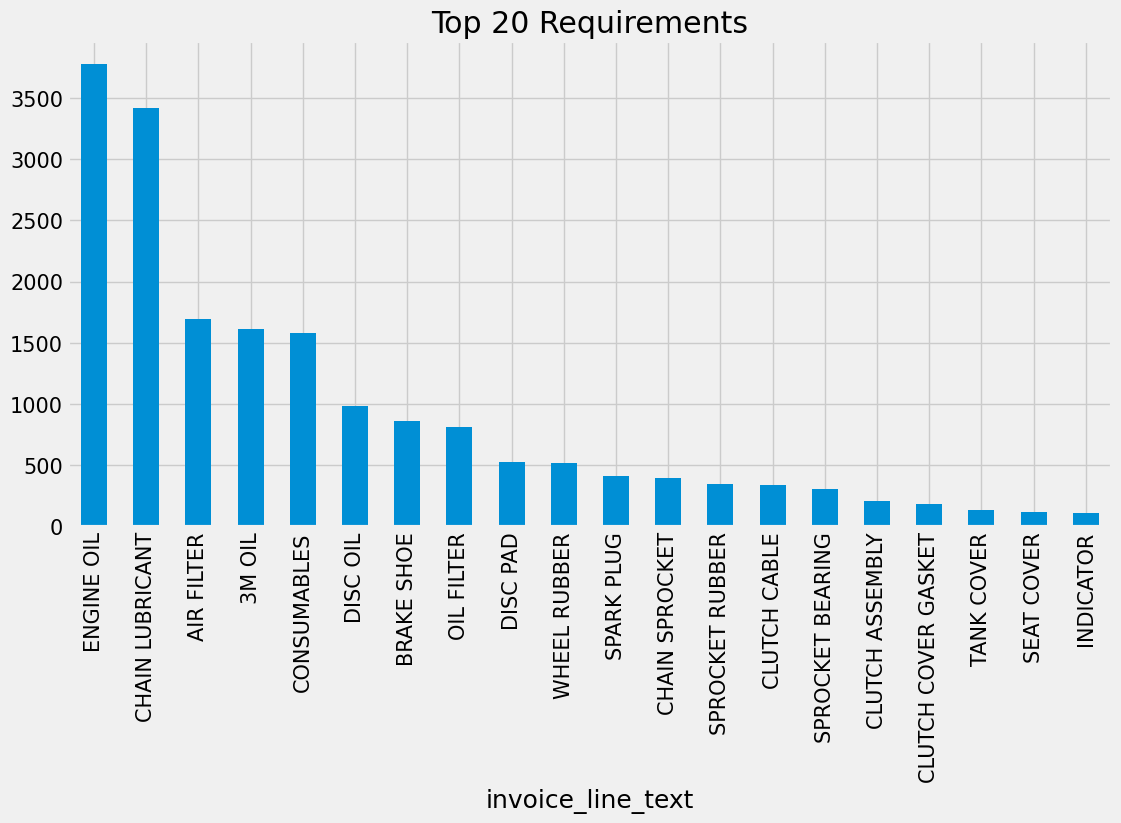

In [58]:
# Top 20 Requirements
df2.invoice_line_text.value_counts().nlargest(20).plot(kind='bar', title="Top 20 Requirements", figsize=(12,6));

### Analysis of target variable with respect to other factors

In [59]:
df1[['vehicle_model','invoice_line_text']].groupby('vehicle_model').describe()

invoice_line_text                              
                                     count unique              top  freq
vehicle_model                                                           
BAJAJ AVENGER STREET                   872     86       ENGINE OIL   171
BAJAJ AVENGER STREET 180                99      9      CONSUMABLES    23
BAJAJ AVENGER STREET 220              3358    177       ENGINE OIL   588
BAJAJ BOXER CT                           1      1       SPARK PLUG     1
BAJAJ CALIBER                           30     19       ENGINE OIL     5
BAJAJ CT 100                          1172     63       ENGINE OIL   241
BAJAJ DISCOVER                         535     98       ENGINE OIL    82
BAJAJ DISCOVER 125                    1111    118       ENGINE OIL   168
BAJAJ DISCOVER 135                      94     39       ENGINE OIL    13
BAJAJ DISCOVER 150                     223     57       ENGINE OIL    36
BAJAJ DOMINAR 400 ABS                    6      6       OIL FILTER     1
BAJAJ PLATINA                          706     56       ENGINE OIL   127
BAJAJ PULSAR 150                      6971    250       ENGINE OIL  1059
BAJAJ PULSAR 180                      1840    144       ENGINE OIL   302
BAJAJ PULSAR 220                      2115    176       ENGINE OIL   335
BAJAJ PULSAR AS 200                    324     72       ENGINE OIL    46
BAJAJ PULSAR LS135                     419     71       ENGINE OIL    53
BAJAJ PULSAR NS 160                    314     35  CHAIN LUBRICANT    58
BAJAJ PULSAR NS 200                   1808    116       ENGINE OIL   296
BAJAJ PULSAR RS 200                    249     38       ENGINE OIL    44
BAJAJ V                                 43     17       ENGINE OIL     9
BAJAJ V125                              78     15  CHAIN LUBRICANT    15
BAJAJ V15                               17      9       ENGINE OIL     3
BAJAJ V150                             564     45       ENGINE OIL    97
BAJAJ WIND 125                           4      4  CHAIN LUBRICANT     1
BAJAJ XCD 125                           21     10       ENGINE OIL     5
BAJAJ XCD 135                           10      7       ENGINE OIL     2
WAVE                                     8      8       ENGINE OIL     1

In [60]:
df1.groupby(['vehicle_model','invoice_line_text']).size().nlargest(15)

vehicle_model             invoice_line_text
BAJAJ PULSAR 150          ENGINE OIL           1059
                          CHAIN LUBRICANT       962
BAJAJ AVENGER STREET 220  ENGINE OIL            588
BAJAJ PULSAR 150          AIR FILTER            546
BAJAJ AVENGER STREET 220  CHAIN LUBRICANT       537
BAJAJ PULSAR 150          3M OIL                396
                          CONSUMABLES           382
                          BRAKE SHOE            348
BAJAJ PULSAR 220          ENGINE OIL            335
BAJAJ PULSAR 150          DISC OIL              320
BAJAJ PULSAR 180          ENGINE OIL            302
BAJAJ AVENGER STREET 220  AIR FILTER            300
BAJAJ PULSAR 220          CHAIN LUBRICANT       296
BAJAJ PULSAR NS 200       ENGINE OIL            296
                          CHAIN LUBRICANT       287
dtype: int64

In [61]:
df1[['business_partner_name','vehicle_model','invoice_line_text']].groupby(['business_partner_name','vehicle_model']).describe().head(50)

invoice_line_text         \
                                                           count unique   
business_partner_name vehicle_model                                       
A J XXXXXXXXXX        BAJAJ PULSAR 180                        17      9   
A VEXXXXXXXXXX        BAJAJ PULSAR NS 200                     19     10   
A jyXXXXXXXXXX        BAJAJ PULSAR NS 200                      5      5   
A suXXXXXXXXXX        BAJAJ PULSAR RS 200                      6      6   
ABHIXXXXXXXXXX        BAJAJ AVENGER STREET 220                 4      4   
                      BAJAJ PULSAR 150                         2      2   
                      BAJAJ PULSAR 180                        29     27   
                      BAJAJ PULSAR AS 200                     14     12   
                      BAJAJ PULSAR NS 200                      6      5   
ABIRXXXXXXXXXX        BAJAJ PULSAR NS 200                      9      7   
ABISXXXXXXXXXX        BAJAJ AVENGER STREET 220                 6      6   
ADHIXXXXXXXXXX        BAJAJ PULSAR 150                        12     12   
ADITXXXXXXXXXX        BAJAJ AVENGER STREET 220                 7      6   
                      BAJAJ PULSAR 150                         5      5   
                      BAJAJ PULSAR 180                         9      9   
ADIVXXXXXXXXXX        BAJAJ PULSAR 150                        20     11   
AISHXXXXXXXXXX        BAJAJ PULSAR 150                         5      5   
AJAYXXXXXXXXXX        BAJAJ AVENGER STREET 220                 8      8   
                      BAJAJ PULSAR 150                         6      5   
AJOSXXXXXXXXXX        BAJAJ PULSAR 150                        14      8   
AKSAXXXXXXXXXX        BAJAJ PULSAR 150                         4      4   
AKSHXXXXXXXXXX        BAJAJ AVENGER STREET 220                 5      5   
ALOKXXXXXXXXXX        BAJAJ CT 100                            24     15   
AMALXXXXXXXXXX        BAJAJ PULSAR NS 200                      5      5   
AMITXXXXXXXXXX        BAJAJ DISCOVER 125                       5      5   
                      BAJAJ PULSAR 150                         5      5   
                      BAJAJ V150                              14      6   
AMOLXXXXXXXXXX        BAJAJ AVENGER STREET 220                36     16   
ANANXXXXXXXXXX        BAJAJ PULSAR 150                        11      7   
                      BAJAJ PULSAR NS 200                     42     22   
ANILXXXXXXXXXX        BAJAJ PULSAR 150                        73     42   
                      BAJAJ PULSAR 180                        16      8   
ANIMXXXXXXXXXX        BAJAJ PULSAR LS135                       4      4   
ANISXXXXXXXXXX        BAJAJ AVENGER STREET 220                 5      5   
                      BAJAJ PULSAR 150                         4      4   
ANJAXXXXXXXXXX        BAJAJ PULSAR 220                        19     12   
ANKIXXXXXXXXXX        BAJAJ PULSAR 180                         3      3   
ANKUXXXXXXXXXX        BAJAJ AVENGER STREET                    12      9   
ANMOXXXXXXXXXX        BAJAJ PULSAR 180                         4      4   
ANOOXXXXXXXXXX        BAJAJ AVENGER STREET 220                18     13   
ANSUXXXXXXXXXX        BAJAJ AVENGER STREET 220                11      8   
ARBIXXXXXXXXXX        BAJAJ DISCOVER                          16     15   
ARPIXXXXXXXXXX        BAJAJ DISCOVER                           5      5   
ARUNXXXXXXXXXX        BAJAJ CT 100                             5      5   
                      BAJAJ PULSAR NS 200                     13      8   
                      BAJAJ PULSAR RS 200                      4      4   
ARVIXXXXXXXXXX        BAJAJ V150                               7      7   
ASHOXXXXXXXXXX        BAJAJ AVENGER STREET 220                11      7   
                      BAJAJ PULSAR AS 200                      9      9   
ASHUXXXXXXXXXX        BAJAJ DISCOVER 150                      15     12   

                                                                      


In [62]:
df1.groupby(['business_partner_name','vehicle_model','invoice_line_text']).size().nlargest(15)

business_partner_name  vehicle_model             invoice_line_text
shivXXXXXXXXXX         BAJAJ PULSAR 150          ENGINE OIL           19
venkXXXXXXXXXX         BAJAJ PULSAR 150          ENGINE OIL           18
shivXXXXXXXXXX         BAJAJ PULSAR 150          CHAIN LUBRICANT      17
venkXXXXXXXXXX         BAJAJ PULSAR 150          CHAIN LUBRICANT      16
prasXXXXXXXXXX         BAJAJ PULSAR 150          ENGINE OIL           15
abhiXXXXXXXXXX         BAJAJ AVENGER STREET 220  ENGINE OIL           14
hariXXXXXXXXXX         BAJAJ PULSAR 150          ENGINE OIL           14
sathXXXXXXXXXX         BAJAJ PULSAR 150          ENGINE OIL           14
srinXXXXXXXXXX         BAJAJ PULSAR 150          ENGINE OIL           14
abhiXXXXXXXXXX         BAJAJ AVENGER STREET 220  CHAIN LUBRICANT      13
hariXXXXXXXXXX         BAJAJ PULSAR 150          CHAIN LUBRICANT      13
prasXXXXXXXXXX         BAJAJ PULSAR 150          CHAIN LUBRICANT      13
dineXXXXXXXXXX         BAJAJ PULSAR 150          ENGINE O

### Target Variable for particular vehicle and particular spare part

In [63]:
df4 = df1[['job_card_date','vehicle_model','invoice_line_text']]
df4.set_index('job_card_date',inplace=True)
df4


,vehicle_model,invoice_line_text
job_card_date,,
2017-05-30,BAJAJ AVENGER STREET 220,ENGINE OIL
2017-05-31,BAJAJ PULSAR NS 200,ENGINE OIL
2017-05-31,BAJAJ PULSAR NS 200,CONSUMABLES
2017-05-31,BAJAJ PULSAR NS 200,COOLANT OIL
2017-05-31,BAJAJ PULSAR NS 200,CHAIN LUBRICANT
...,...,...
2019-01-06,BAJAJ DISCOVER 125,SPROCKET RUBBER
2019-01-06,BAJAJ DISCOVER 125,CLUTCH CABLE
2019-01-06,BAJAJ DISCOVER 125,OIL FILTER


In [64]:
df4.loc[(df4['vehicle_model']=='BAJAJ PULSAR 150')&(df4['invoice_line_text']=='ENGINE OIL')]

,vehicle_model,invoice_line_text
job_card_date,,
2017-05-31,BAJAJ PULSAR 150,ENGINE OIL
2017-06-01,BAJAJ PULSAR 150,ENGINE OIL
2017-06-01,BAJAJ PULSAR 150,ENGINE OIL
2017-06-02,BAJAJ PULSAR 150,ENGINE OIL
2017-06-03,BAJAJ PULSAR 150,ENGINE OIL
...,...,...
2019-01-05,BAJAJ PULSAR 150,ENGINE OIL
2019-01-05,BAJAJ PULSAR 150,ENGINE OIL
2019-01-05,BAJAJ PULSAR 150,ENGINE OIL


In [65]:
df5 = df4.loc[(df4['vehicle_model']=='BAJAJ PULSAR 150')&(df4['invoice_line_text']=='ENGINE OIL')]
df5 = df5['invoice_line_text'].resample('W').count()
df5

job_card_date
2017-06-04     6
2017-06-11    13
2017-06-18    14
2017-06-25    13
2017-07-02    11
              ..
2018-12-09    15
2018-12-16    12
2018-12-23    15
2018-12-30    21
2019-01-06    15
Freq: W-SUN, Name: invoice_line_text, Length: 84, dtype: int64

In [66]:
models = ['BAJAJ PULSAR 150','BAJAJ AVENGER STREET 220','BAJAJ PULSAR 220','BAJAJ PULSAR 180','BAJAJ PULSAR NS 200']
labels =['ENGINE OIL','CHAIN LUBRICANT','AIR FILTER','3M OIL','CONSUMABLES','BRAKE SHOE','DISC OIL']
Vehicle_Spares = []
for model in models:
    for text in labels:
        filename=(model.replace(' ','_'))+'_'+(text.replace(' ','_'))
        tempDf=df4.loc[(df4['vehicle_model']==model)&(df4['invoice_line_text']==text)]
        tempDf=tempDf['invoice_line_text'].resample('W').count().to_frame()
        colname=filename+'_'+'Weekly_Count'
        tempDf = tempDf.rename(columns={'invoice_line_text':colname})
        Vehicle_Spares.append(tempDf)
        tempDf.to_csv(filename + '.csv')


In [67]:
Vehicle_Spares[0]

,BAJAJ_PULSAR_150_ENGINE_OIL_Weekly_Count
job_card_date,
2017-06-04,6
2017-06-11,13
2017-06-18,14
2017-06-25,13
2017-07-02,11
...,...
2018-12-09,15
2018-12-16,12
2018-12-23,15


### Time Series Implementation 

In [68]:
BAJAJPULSAR150EngineOilWeeklyCount = Vehicle_Spares[0].copy()
BAJAJPULSAR150EngineOilWeeklyCount

,BAJAJ_PULSAR_150_ENGINE_OIL_Weekly_Count
job_card_date,
2017-06-04,6
2017-06-11,13
2017-06-18,14
2017-06-25,13
2017-07-02,11
...,...
2018-12-09,15
2018-12-16,12
2018-12-23,15


In [69]:
BAJAJPULSAR150EngineOilWeeklyCount = BAJAJPULSAR150EngineOilWeeklyCount.squeeze()
BAJAJPULSAR150EngineOilWeeklyCount


job_card_date
2017-06-04     6
2017-06-11    13
2017-06-18    14
2017-06-25    13
2017-07-02    11
              ..
2018-12-09    15
2018-12-16    12
2018-12-23    15
2018-12-30    21
2019-01-06    15
Freq: W-SUN, Name: BAJAJ_PULSAR_150_ENGINE_OIL_Weekly_Count, Length: 84, dtype: int64

In [70]:
def check_stationarity(ts):
    dftest = adfuller(ts)
    adf = dftest[0]
    pvalue = dftest[1]
    critical_value = dftest[4]['5%']
    if (pvalue < 0.05) and (adf < critical_value):
        print('The series is stationary')
    else:
        print('The series is NOT stationary')

In [71]:
check_stationarity(BAJAJPULSAR150EngineOilWeeklyCount)


The series is stationary


<Axes: xlabel='job_card_date'>

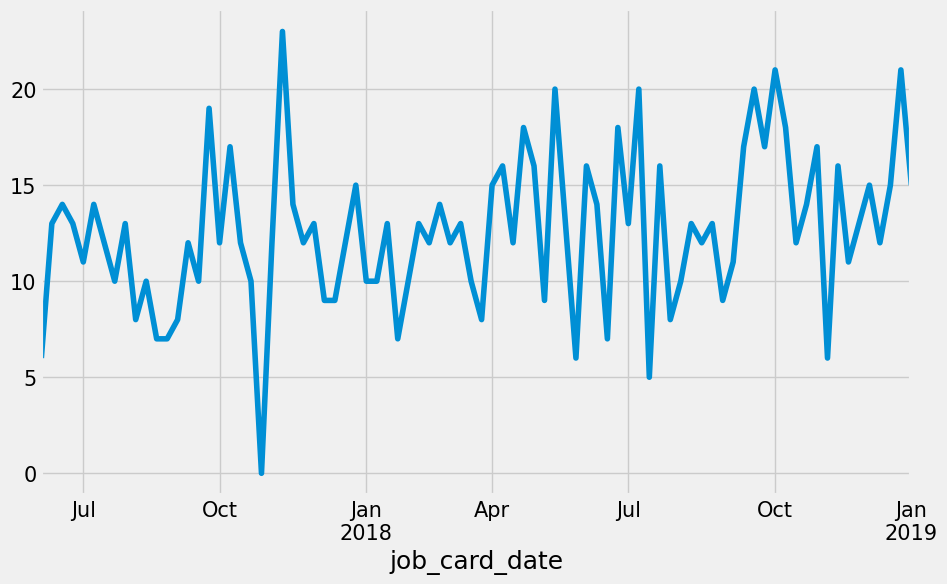

In [72]:
BAJAJPULSAR150EngineOilWeeklyCount.plot()

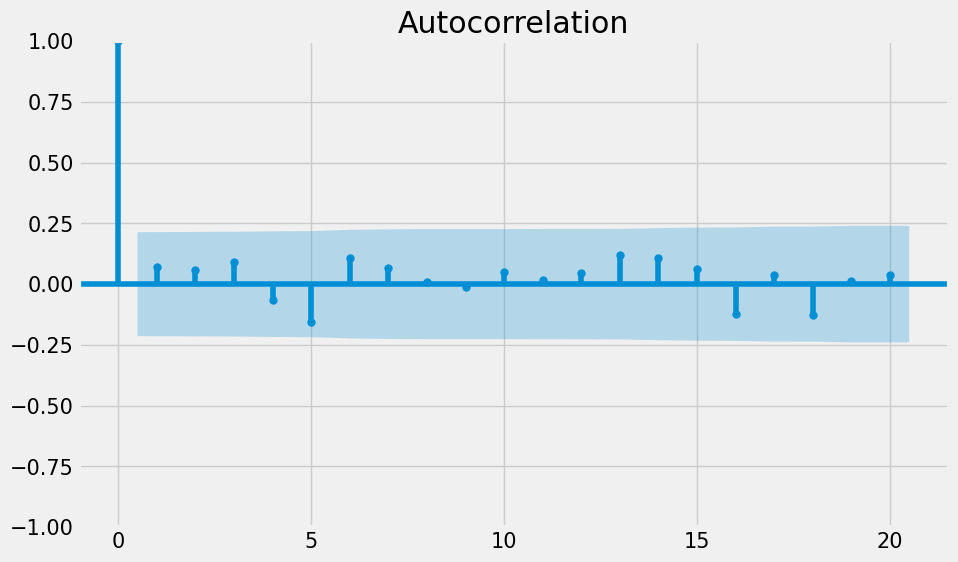

In [73]:
plot_acf(BAJAJPULSAR150EngineOilWeeklyCount)
plt.show()

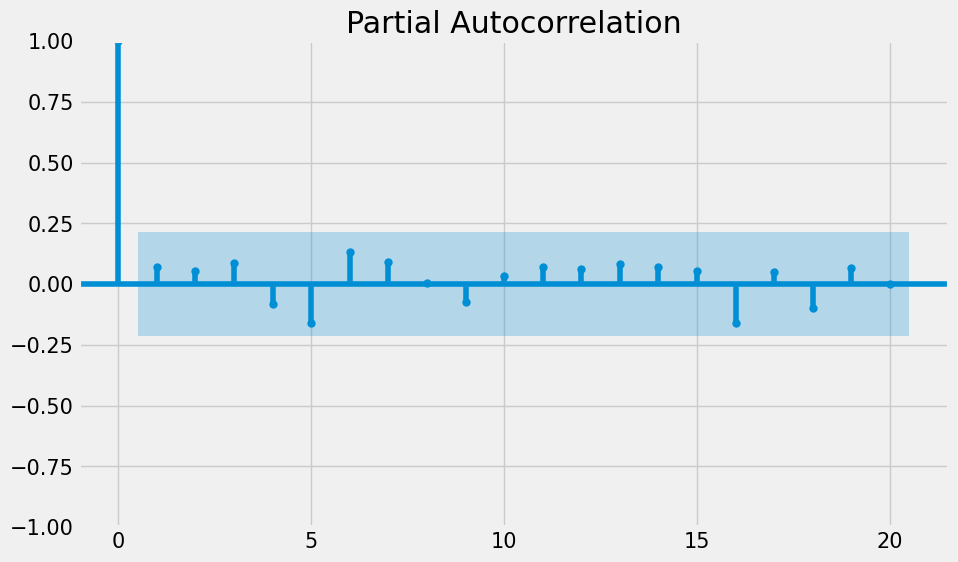

In [74]:
plot_pacf(BAJAJPULSAR150EngineOilWeeklyCount)
plt.show()

In [75]:
def find_period(signal):
    acf = np.correlate(signal, signal, 'full')[-len(signal):]
    inflection = np.diff(np.sign(np.diff(acf)))
    peaks = (inflection < 0).nonzero()[0] + 1
    return peaks[acf[peaks].argmax()]

In [76]:
find_period(BAJAJPULSAR150EngineOilWeeklyCount)

np.int64(6)

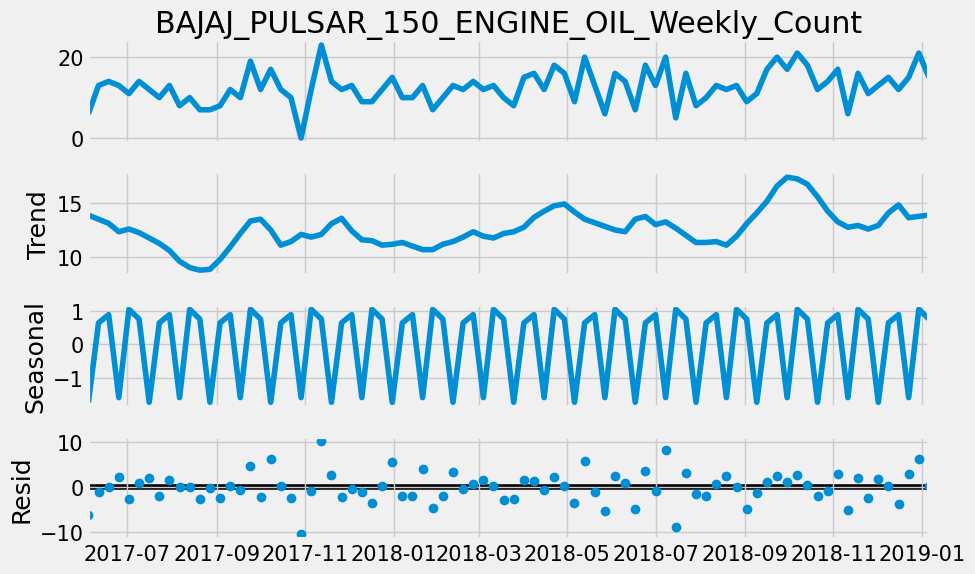

In [77]:
result = seasonal_decompose(BAJAJPULSAR150EngineOilWeeklyCount, model='additive',extrapolate_trend='freq',period=6)
result.plot()
plt.show()

The series is stationary


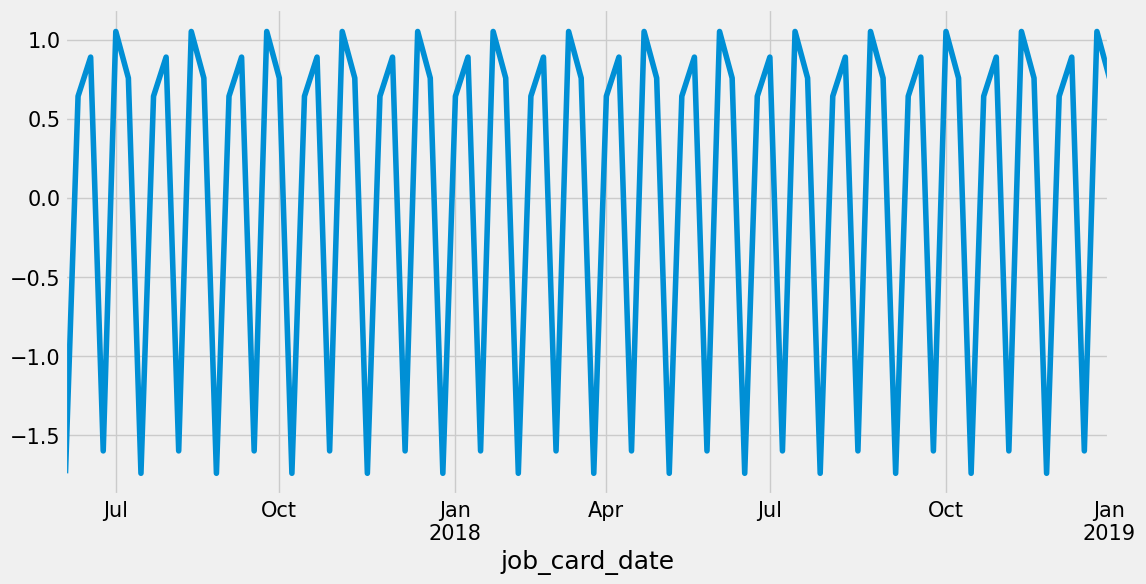

In [78]:
seasonal = result.seasonal
seasonal.plot(figsize=(12,6))
check_stationarity(seasonal)

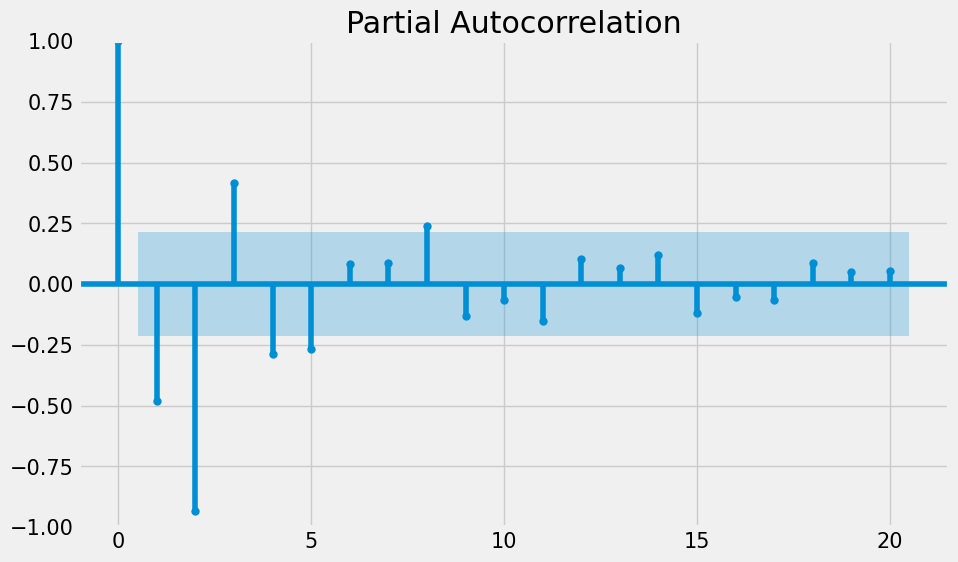

In [79]:
plot_pacf(seasonal)
plt.show()

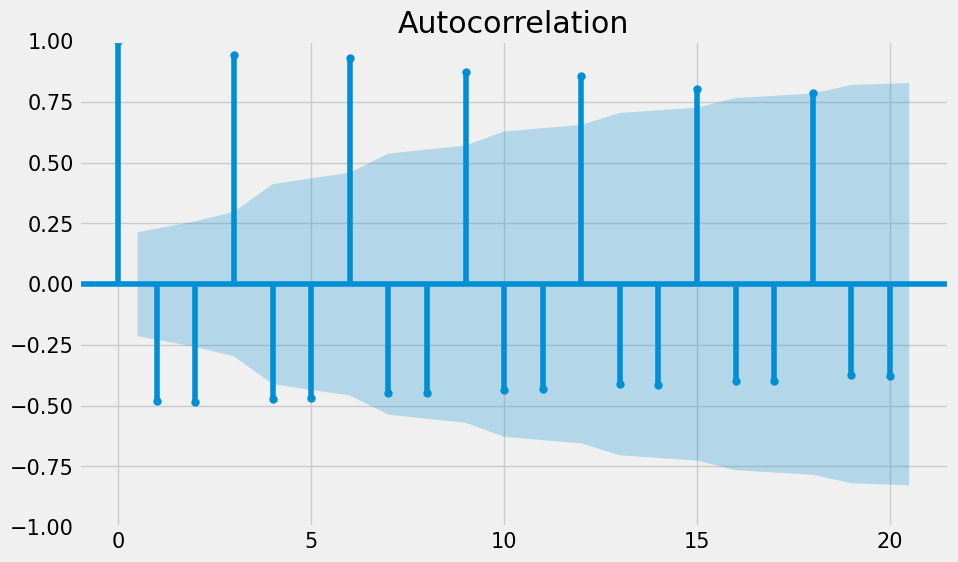

In [80]:
plot_acf(seasonal)
plt.show()


In [81]:
train=BAJAJPULSAR150EngineOilWeeklyCount[:69]
test=BAJAJPULSAR150EngineOilWeeklyCount[69:]

In [82]:
train.shape

(69,)

# modeling accuracy

In [83]:
def forecast_accuracy(model,forecast, actual):
    AIC = model.aic
    MAD = np.mean(np.abs(forecast - actual))
    MSE = np.mean((forecast - actual)**2)
    RMSE = np.mean((forecast - actual)**2)**.5
    MAPE = np.mean(np.abs(forecast - actual)/np.abs(actual))*100
    return({'AIC': AIC,'MAD': MAD, 'MSE': MSE ,'RMSE': RMSE, 'MAPE': MAPE})

In [84]:
base = BAJAJPULSAR150EngineOilWeeklyCount.copy()
base = base.to_frame(name='BAJAJPULSAR150_ENGINEOIL_Weekly_Count')
base

,BAJAJPULSAR150_ENGINEOIL_Weekly_Count
job_card_date,
2017-06-04,6
2017-06-11,13
2017-06-18,14
2017-06-25,13
2017-07-02,11
...,...
2018-12-09,15
2018-12-16,12
2018-12-23,15


In [85]:
base_diff = pd.concat([base,base.shift(1)],axis=1)

In [86]:
base_diff

,BAJAJPULSAR150_ENGINEOIL_Weekly_Count,BAJAJPULSAR150_ENGINEOIL_Weekly_Count
job_card_date,,
2017-06-04,6,NaN
2017-06-11,13,6.0
2017-06-18,14,13.0
2017-06-25,13,14.0
2017-07-02,11,13.0
...,...,...
2018-12-09,15,13.0
2018-12-16,12,15.0
2018-12-23,15,12.0


In [87]:
base_diff.columns = ['Actual_Count','Forecast_Count']

In [88]:
base_diff.dropna(inplace=True)

In [89]:
MAD = np.mean(np.abs(base_diff.Forecast_Count - base_diff.Actual_Count))
MSE = np.mean((base_diff.Forecast_Count - base_diff.Actual_Count)**2)
RMSE = np.mean((base_diff.Forecast_Count - base_diff.Actual_Count)**2)**.5
print('Mean Absolute Deviation of Naive Model is: ',MAD)
print('Mean Squared Error of Naive Model is: ',MSE)
print('Root Mean Squared Error of Naive Model is: ',RMSE)

Mean Absolute Deviation of Naive Model is:  4.469879518072289
Mean Squared Error of Naive Model is:  30.83132530120482
Root Mean Squared Error of Naive Model is:  5.552596266721075


#  ARIMA

In [90]:
model_arima = ARIMA(train, order=(5,0,5))
model_arima_fit = model_arima.fit()


In [91]:
predictions = model_arima_fit.forecast(steps=15)
predictions

2018-09-30    12.423159
2018-10-07    13.084911
2018-10-14    11.191070
2018-10-21     9.624393
2018-10-28    11.158647
2018-11-04    13.680521
2018-11-11    12.882103
2018-11-18    12.154826
2018-11-25    12.446929
2018-12-02    11.861907
2018-12-09    11.148773
2018-12-16    12.033748
2018-12-23    12.693817
2018-12-30    12.221196
2019-01-06    12.068217
Freq: W-SUN, Name: predicted_mean, dtype: float64

In [92]:
forecast_accuracy(model_arima_fit,predictions,test)

{'AIC': np.float64(405.2400640441016),
 'MAD': np.float64(3.9367562865172436),
 'MSE': np.float64(21.736350824490234),
 'RMSE': np.float64(4.66222595167697),
 'MAPE': np.float64(28.358769510734767)}

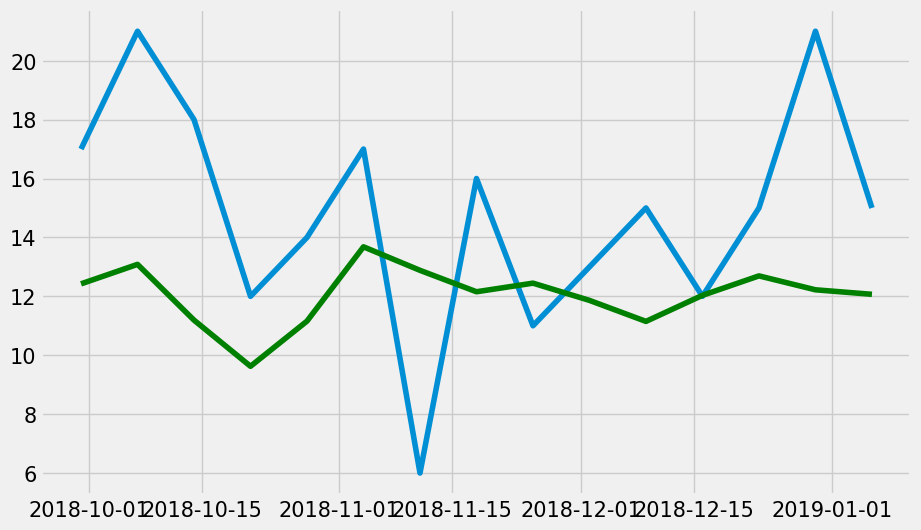

In [93]:
plt.plot(test)
plt.plot(predictions,color='green')

## HYPERPARAMETER TUNING ARIMA

In [94]:
p=q=range(0,6)
d=range(0,2)
pdq = list(itertools.product(p,d,q))
arima_metric_dict = dict()

In [95]:
for params in pdq:
    try:
        model_arima = ARIMA(train, order=params,)
        model_arima_fit = model_arima.fit()
        pred = model_arima_fit.forecast(steps=15)
        rmse = np.sqrt(mean_squared_error(test,pred))
        arima_metric_dict.update({(params):[model_arima_fit.aic,rmse]})
    except:
        continue

In [96]:
arima_aic_sorted_results = {k:v for k,v in sorted(arima_metric_dict.items(),key=lambda x: x[1][0])}
arima_aic_sorted_results_top10 = dict(list(arima_aic_sorted_results.items())[0: 10])
arima_aic_sorted_results_df_top10 = pd.DataFrame(arima_aic_sorted_results_top10)
arima_aic_sorted_results_df_top10 = arima_aic_sorted_results_df_top10.T
arima_aic_sorted_results_df_top10.columns = ['AIC','RMSE']
arima_aic_sorted_results_df_top10

AIC      RMSE
0 1 1  390.163082  4.391249
  0 0  390.813479  4.642062
  1 2  392.149753  4.393141
1 1 1  392.151410  4.392636
0 0 1  392.793713  4.652990
1 0 0  392.796215  4.651196
2 1 2  392.910669  4.003755
1 1 3  392.931694  4.011083
0 1 3  393.836327  4.480081
2 1 1  393.917579  4.457070

In [97]:
arima_rmse_sorted_results = {k:v for k,v in sorted(arima_metric_dict.items(),key=lambda x: x[1][1])}
arima_rmse_sorted_results_top10 = dict(list(arima_rmse_sorted_results.items())[0: 10])
arima_rmse_sorted_results_df_top10 = pd.DataFrame(arima_rmse_sorted_results_top10)
arima_rmse_sorted_results_df_top10 = arima_rmse_sorted_results_df_top10.T
arima_rmse_sorted_results_df_top10.columns = ['AIC','RMSE']
arima_rmse_sorted_results_df_top10


AIC      RMSE
5 1 0  404.184219  3.730141
2 1 2  392.910669  4.003755
1 1 3  392.931694  4.011083
4 1 0  409.330817  4.048847
3 1 4  398.838600  4.087697
2 1 4  396.948500  4.111785
3 1 0  407.762521  4.141513
4 1 4  400.415167  4.318406
    5  401.756966  4.338066
5 1 3  398.300793  4.356175

In [98]:
model_arima = ARIMA(train, order=(5,1,0))
model_arima_fit = model_arima.fit()

In [99]:
prediction = model_arima_fit.forecast(steps=15)
prediction

2018-09-30    14.302006
2018-10-07    14.929288
2018-10-14    13.919709
2018-10-21    13.814980
2018-10-28    15.158437
2018-11-04    16.251583
2018-11-11    14.797879
2018-11-18    15.043999
2018-11-25    14.841394
2018-12-02    14.672783
2018-12-09    14.948888
2018-12-16    15.310894
2018-12-23    14.930710
2018-12-30    15.009111
2019-01-06    14.983485
Freq: W-SUN, Name: predicted_mean, dtype: float64

In [100]:
forecast_accuracy(model_arima_fit,predictions,test)

{'AIC': np.float64(404.18421899940944),
 'MAD': np.float64(3.9367562865172436),
 'MSE': np.float64(21.736350824490234),
 'RMSE': np.float64(4.66222595167697),
 'MAPE': np.float64(28.358769510734767)}

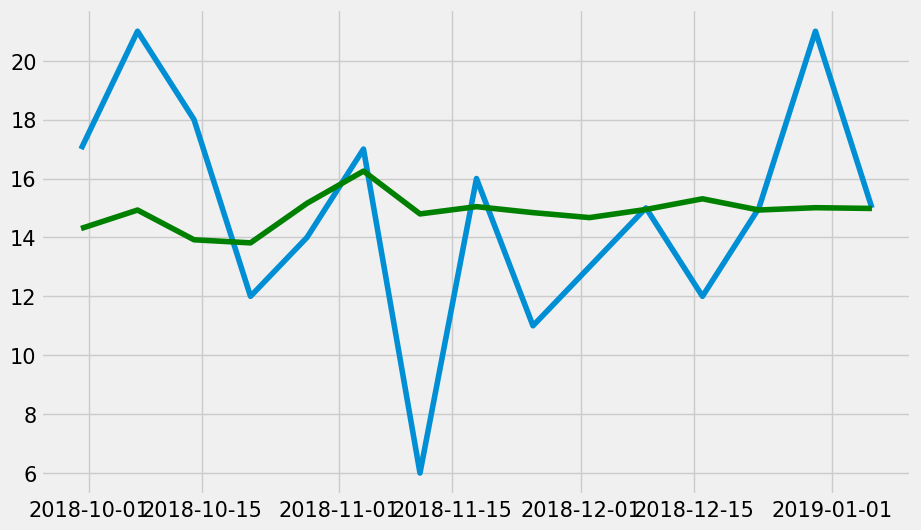

In [101]:
plt.plot(test)
plt.plot(prediction,color='green')

In [102]:
print("TEST 1")

print("Train length:", len(train))
print("Test length:", len(test))

print("Train:")
print(train.head())

print("Test:")
print(test.head())

TEST 1
Train length: 69
Test length: 15
Train:
job_card_date
2017-06-04     6
2017-06-11    13
2017-06-18    14
2017-06-25    13
2017-07-02    11
Freq: W-SUN, Name: BAJAJ_PULSAR_150_ENGINE_OIL_Weekly_Count, dtype: int64
Test:
job_card_date
2018-09-30    17
2018-10-07    21
2018-10-14    18
2018-10-21    12
2018-10-28    14
Freq: W-SUN, Name: BAJAJ_PULSAR_150_ENGINE_OIL_Weekly_Count, dtype: int64


#srima 

In [103]:
BAJAJPULSAR150CHAINLUBRICANTWeeklyCount = Vehicle_Spares[1].copy()

print(BAJAJPULSAR150CHAINLUBRICANTWeeklyCount.head())
print("Total observations:", len(BAJAJPULSAR150CHAINLUBRICANTWeeklyCount))

               BAJAJ_PULSAR_150_CHAIN_LUBRICANT_Weekly_Count
job_card_date                                               
2017-06-04                                                 6
2017-06-11                                                12
2017-06-18                                                15
2017-06-25                                                13
2017-07-02                                                11
Total observations: 84


## Train / Test

In [104]:
train = BAJAJPULSAR150CHAINLUBRICANTWeeklyCount.iloc[:69]
test = BAJAJPULSAR150CHAINLUBRICANTWeeklyCount.iloc[69:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 69
Test size: 15


## Hyperparameter combinations

In [108]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pandas.tseries.offsets import DateOffset

p = range(0, 3)
d = range(0, 2)
q = range(0, 3)

pdq = list(itertools.product(p, d, q))

seasonal_pdq = [
    (P, D, Q, 9)
    for P, D, Q in itertools.product(
        range(0, 3),
        range(0, 2),
        range(0, 3)
    )
]

print("Non-seasonal combinations:", len(pdq))
print("Seasonal combinations:", len(seasonal_pdq))
print("Total models:", len(pdq) * len(seasonal_pdq))

Non-seasonal combinations: 18
Seasonal combinations: 18
Total models: 324


## SARIMAX Hyperparameter Tuning

In [109]:
metric_dict = {}

for pm in pdq:
    for seasonal_pm in seasonal_pdq:

        try:
            model = SARIMAX(
                train,
                order=pm,
                seasonal_order=seasonal_pm,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            results = model.fit(
                disp=False,
                maxiter=100
            )

            # Forecast exactly 15 test observations
            y_predicted = results.forecast(
                steps=len(test)
            )

            y_true = test

            mse = np.mean(
                (np.asarray(y_predicted) - np.asarray(y_true)) ** 2
            )

            rmse = np.sqrt(mse)

            metric_dict[(pm, seasonal_pm)] = [
                results.aic,
                rmse
            ]

        except Exception:
            continue

print("Successful models:", len(metric_dict))

Successful models: 324


## Best 10 models based on RMSE 

In [130]:
stable_models = {}

for params, metrics in metric_dict.items():
    aic, rmse = metrics

    if np.isfinite(aic) and np.isfinite(rmse):
        if rmse < 100:      
            stable_models[params] = [aic, rmse]

print("Stable models:", len(stable_models))

Stable models: 271


In [131]:
sorted_stable = sorted(
    stable_models.items(),
    key=lambda x: x[1][1]
)

for i, (params, metrics) in enumerate(sorted_stable[:10]):
    print(
        i + 1,
        "Order =", params[0],
        "Seasonal =", params[1],
        "AIC =", metrics[0],
        "RMSE =", metrics[1]
    )

1 Order = (1, 1, 1) Seasonal = (2, 1, 2, 9) AIC = 1576.1863629991344 RMSE = 3.4962238580379923
2 Order = (0, 1, 1) Seasonal = (2, 1, 2, 9) AIC = 1444.8770332029862 RMSE = 3.5708444578316736
3 Order = (2, 1, 1) Seasonal = (2, 1, 2, 9) AIC = 1450.091238409116 RMSE = 3.629341725337882
4 Order = (1, 0, 1) Seasonal = (2, 0, 0, 9) AIC = 297.75821457113875 RMSE = 3.677448020255966
5 Order = (2, 0, 2) Seasonal = (2, 0, 0, 9) AIC = 295.48878356773037 RMSE = 3.6846228914378445
6 Order = (1, 0, 2) Seasonal = (2, 0, 0, 9) AIC = 299.4524703479798 RMSE = 3.7251425251897996
7 Order = (2, 0, 2) Seasonal = (2, 0, 1, 9) AIC = 296.5315553727138 RMSE = 3.740193541438252
8 Order = (2, 0, 2) Seasonal = (1, 0, 0, 9) AIC = 344.1492921704352 RMSE = 3.782728885218246
9 Order = (1, 0, 1) Seasonal = (1, 0, 0, 9) AIC = 346.2511323687822 RMSE = 3.782766850714356
10 Order = (1, 0, 1) Seasonal = (2, 0, 1, 9) AIC = 298.7876367093221 RMSE = 3.7839037104076105


In [132]:
best_order = top10[0][0][0]
best_seasonal_order = top10[0][0][1]

best_aic = top10[0][1][0]
best_rmse = top10[0][1][1]

print("Best Order:", best_order)
print("Best Seasonal Order:", best_seasonal_order)
print("Best AIC:", best_aic)
print("Best RMSE:", best_rmse)

Best Order: (1, 0, 1)
Best Seasonal Order: (1, 0, 0, 9)
Best AIC: 338.5816914768687
Best RMSE: 3.717237843594447


## Best SARIMAX model

In [133]:
model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(
    disp=False,
    maxiter=200
)

print(results.summary())

                                          SARIMAX Results                                           
Dep. Variable:     BAJAJ_PULSAR_150_ENGINE_OIL_Weekly_Count   No. Observations:                   69
Model:                       SARIMAX(1, 0, 1)x(1, 0, [], 9)   Log Likelihood                -169.126
Date:                                      Fri, 14 Aug 2026   AIC                            346.251
Time:                                              20:51:14   BIC                            354.561
Sample:                                          06-04-2017   HQIC                           349.495
                                               - 09-23-2018                                         
Covariance Type:                                        opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0041      0.003  

In [134]:
results.predict(start=69, end=83)

2018-09-30    14.183314
2018-10-07    14.088750
2018-10-14    13.916897
2018-10-21    14.055433
2018-10-28    14.039149
2018-11-04    14.410789
2018-11-11    14.317471
2018-11-18    13.914265
2018-11-25    13.743918
2018-12-02    14.257427
2018-12-09    14.327527
2018-12-16    14.403876
2018-12-23    14.456416
2018-12-30    14.521219
2019-01-06    14.556204
Freq: W-SUN, Name: predicted_mean, dtype: float64

In [135]:
y_predicted = results.forecast(
    steps=len(test)
)

y_true = test.copy()

print(y_predicted)

2018-09-30    14.183314
2018-10-07    14.088750
2018-10-14    13.916897
2018-10-21    14.055433
2018-10-28    14.039149
2018-11-04    14.410789
2018-11-11    14.317471
2018-11-18    13.914265
2018-11-25    13.743918
2018-12-02    14.257427
2018-12-09    14.327527
2018-12-16    14.403876
2018-12-23    14.456416
2018-12-30    14.521219
2019-01-06    14.556204
Freq: W-SUN, Name: predicted_mean, dtype: float64


In [136]:
forecast_accuracy(
    results,
    y_predicted,
    y_true
)

{'AIC': np.float64(346.2511323687822),
 'MAD': np.float64(2.896126098251235),
 'MSE': np.float64(14.309325046863405),
 'RMSE': np.float64(3.782766850714356),
 'MAPE': np.float64(23.53527719398664)}

In [137]:
mse = np.mean(
    (np.asarray(y_predicted) - np.asarray(y_true)) ** 2
)

rmse = np.sqrt(mse)

mad = np.mean(
    np.abs(np.asarray(y_predicted) - np.asarray(y_true))
)

print("MAD :", mad)
print("MSE :", mse)
print("RMSE:", rmse)

MAD : 2.896126098251235
MSE : 14.309325046863405
RMSE: 3.782766850714356


## Actual vs SARIMAX forecast

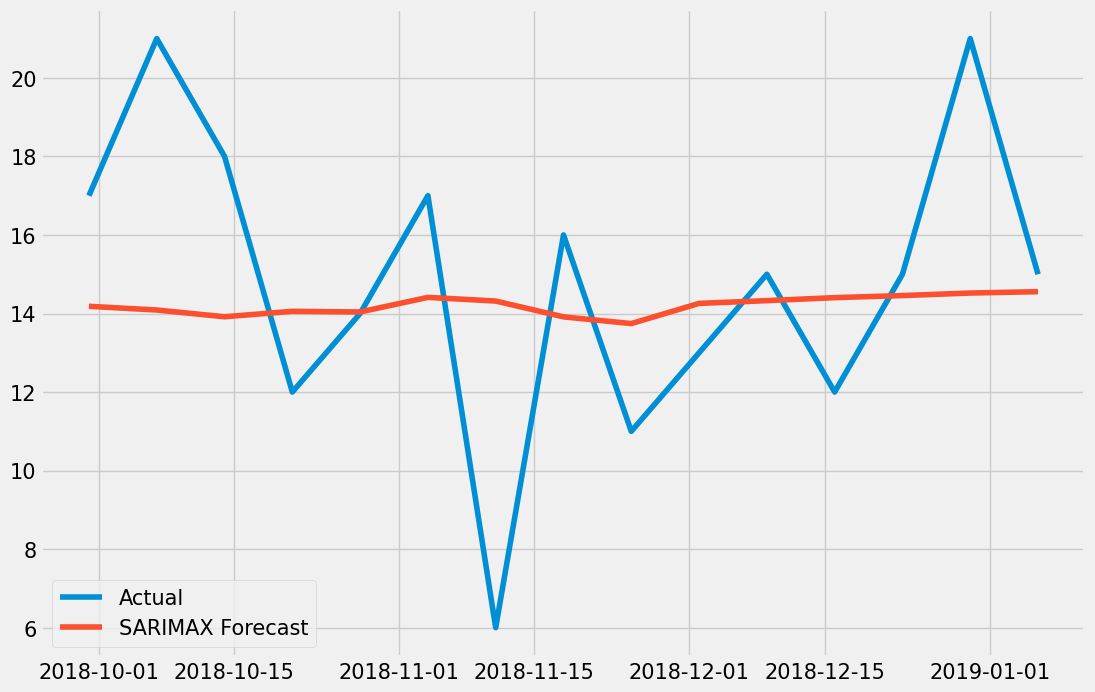

In [138]:
plt.figure(figsize=(12, 8))

plt.plot(
    test.index,
    test,
    label='Actual'
)

plt.plot(
    test.index,
    y_predicted,
    label='SARIMAX Forecast'
)

plt.legend()
plt.show()

## Future 14-week forecast

In [139]:
final_model = SARIMAX(
    BAJAJPULSAR150EngineOilWeeklyCount,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_results = final_model.fit(
    disp=False,
    maxiter=200
)

In [140]:
future_forecast = final_results.forecast(
    steps=14
)

print(future_forecast)

2019-01-13    16.125552
2019-01-20    15.031419
2019-01-27    15.696683
2019-02-03    15.541434
2019-02-10    15.386556
2019-02-17    15.818393
2019-02-24    15.546991
2019-03-03    14.924159
2019-03-10    15.708927
2019-03-17    15.658470
2019-03-24    15.868694
2019-03-31    15.872978
2019-04-07    15.973866
2019-04-14    16.075097
Freq: W-SUN, Name: predicted_mean, dtype: float64


##   Actual + Future Forecast graph

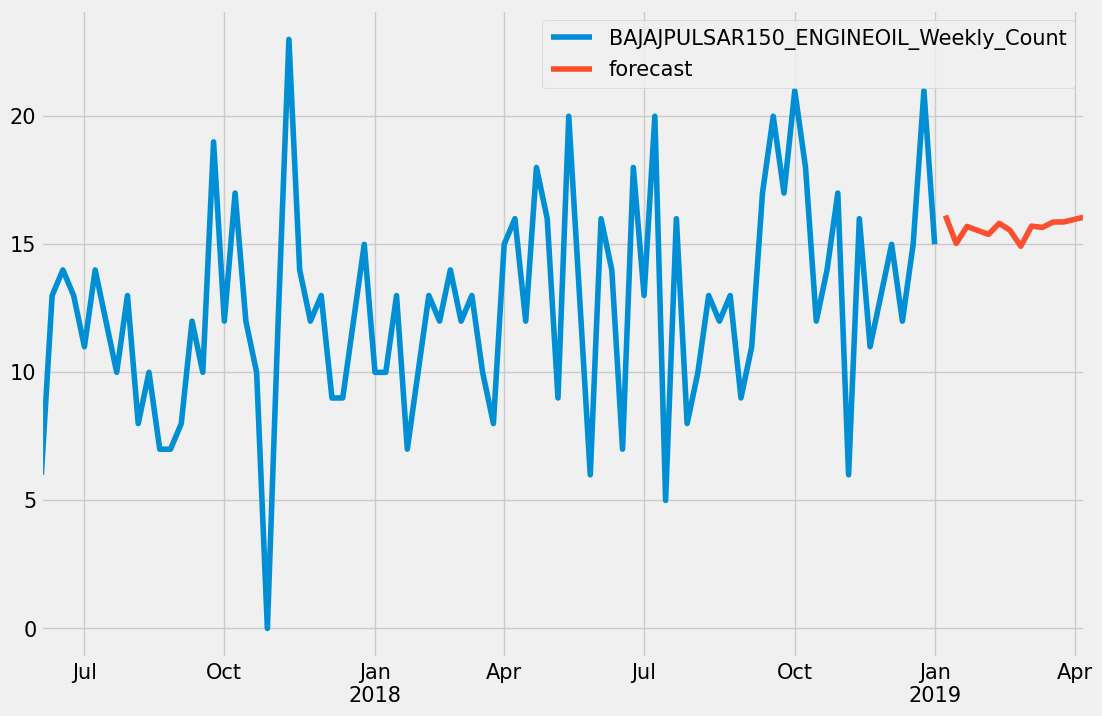

In [141]:
data = BAJAJPULSAR150EngineOilWeeklyCount.copy()

data = data.to_frame(
    name='BAJAJPULSAR150_ENGINEOIL_Weekly_Count'
)

future_dates = pd.date_range(
    start=data.index[-1] + DateOffset(weeks=1),
    periods=14,
    freq='W-SUN'
)

forecast_data = pd.DataFrame(
    {
        'forecast': future_forecast.values
    },
    index=future_dates
)

plot_data = pd.concat(
    [
        data,
        forecast_data
    ],
    axis=0
)

plot_data[
    [
        'BAJAJPULSAR150_ENGINEOIL_Weekly_Count',
        'forecast'
    ]
].plot(figsize=(12, 8))

plt.show()

In [142]:
forecast_table = pd.DataFrame({
    'Date': future_dates,
    'Forecast': future_forecast.values
})

forecast_table

,Date,Forecast
0,2019-01-13,16.125552
1,2019-01-20,15.031419
2,2019-01-27,15.696683
3,2019-02-03,15.541434
4,2019-02-10,15.386556
5,2019-02-17,15.818393
6,2019-02-24,15.546991
7,2019-03-03,14.924159
8,2019-03-10,15.708927
9,2019-03-17,15.658470


In [143]:
forecast_table.to_csv(
    'BAJAJPULSAR150_EngineOil_SARIMAX_Forecast.csv',
    index=False
)

print("Forecast saved successfully")

Forecast saved successfully


In [144]:
actual = np.asarray(test)
predicted = np.asarray(y_predicted)

MAD = np.mean(np.abs(actual - predicted))

MSE = np.mean((actual - predicted) ** 2)

RMSE = np.sqrt(MSE)

MAPE = np.mean(
    np.abs((actual - predicted) / actual)
) * 100

print("MAD :", MAD)
print("MSE :", MSE)
print("RMSE:", RMSE)
print("MAPE:", MAPE)

MAD : 2.896126098251235
MSE : 14.309325046863405
RMSE: 3.782766850714356
MAPE: 23.53527719398664


In [145]:
performance = pd.DataFrame({
    'Model': ['SARIMAX'],
    'AIC': [results.aic],
    'MAD': [MAD],
    'MSE': [MSE],
    'RMSE': [RMSE],
    'MAPE': [MAPE]
})

performance

,Model,AIC,MAD,MSE,RMSE,MAPE
0,SARIMAX,346.251132,2.896126,14.309325,3.782767,23.535277


In [146]:
print("Actual:")
print(test.values)

print("\nPredicted:")
print(y_predicted.values)

Actual:
[17 21 18 12 14 17  6 16 11 13 15 12 15 21 15]

Predicted:
[14.18331443 14.08874977 13.91689744 14.0554333  14.03914854 14.41078897
 14.31747095 13.91426544 13.74391826 14.25742699 14.32752675 14.40387556
 14.45641601 14.52121913 14.55620418]


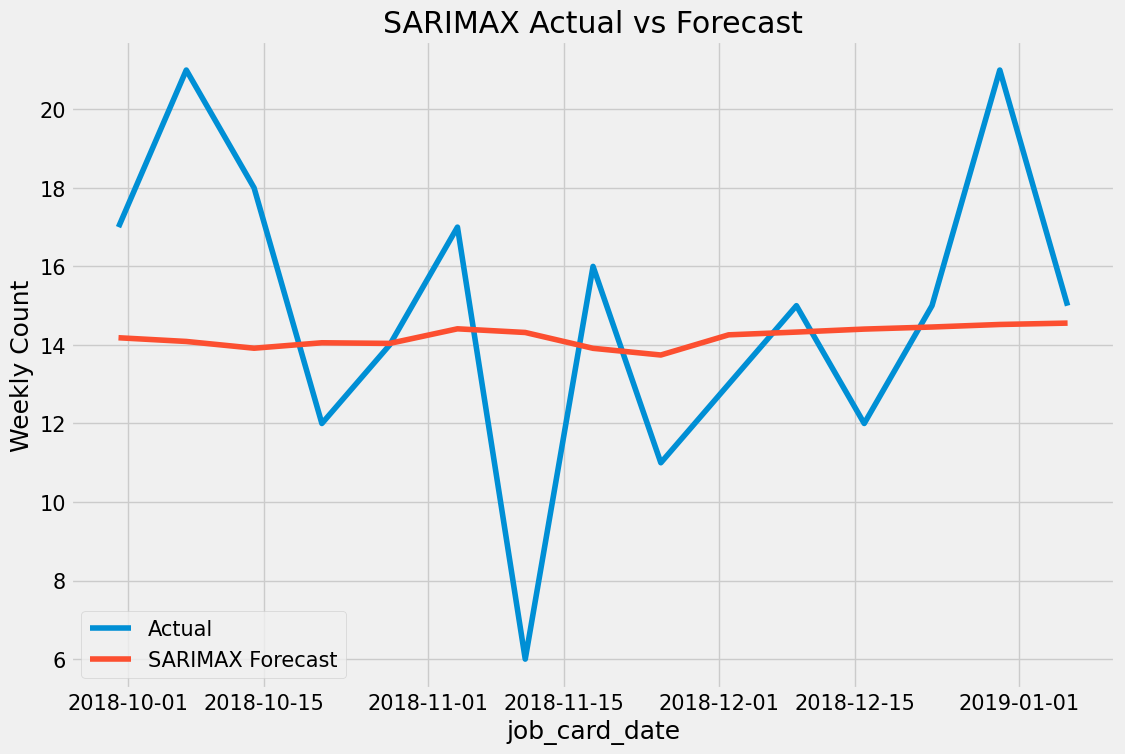

In [147]:
plt.figure(figsize=(12, 8))

plt.plot(
    test.index,
    test.values,
    label='Actual'
)

plt.plot(
    test.index,
    y_predicted.values,
    label='SARIMAX Forecast'
)

plt.xlabel('job_card_date')
plt.ylabel('Weekly Count')
plt.title('SARIMAX Actual vs Forecast')

plt.legend()
plt.grid(True)
plt.show()

## Comparison Table

In [148]:
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMAX'],
    'AIC': [404.184219, 346.251132],
    'MAD': [3.936756, 2.896126],
    'MSE': [21.736351, 14.309325],
    'RMSE': [4.662226, 3.782767],
    'MAPE': [28.358770, 23.535277]
})

comparison

,Model,AIC,MAD,MSE,RMSE,MAPE
0,ARIMA,404.184219,3.936756,21.736351,4.662226,28.358770
1,SARIMAX,346.251132,2.896126,14.309325,3.782767,23.535277


## Comparison Graph — RMSE

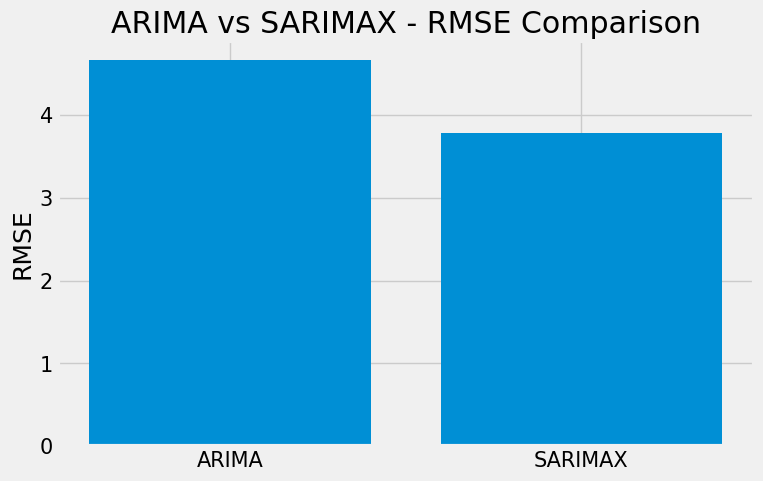

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    comparison['Model'],
    comparison['RMSE']
)

plt.ylabel('RMSE')
plt.title('ARIMA vs SARIMAX - RMSE Comparison')

plt.show()

## Comparison Graph — MAPE

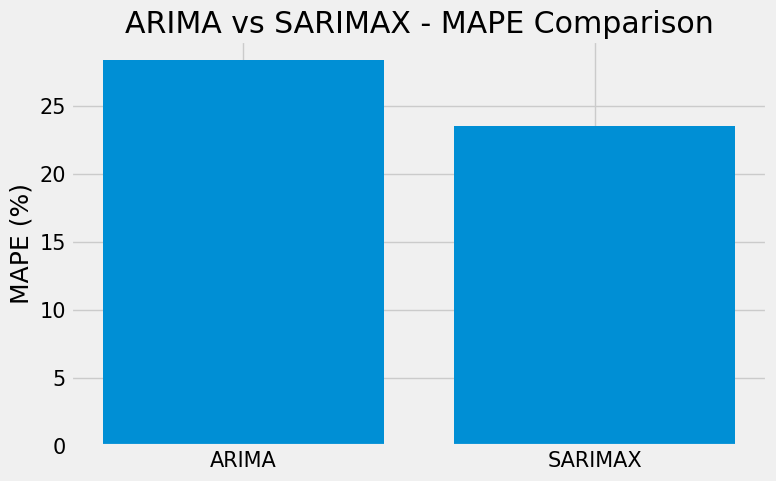

In [151]:
plt.figure(figsize=(8, 5))

plt.bar(
    ['ARIMA', 'SARIMAX'],
    [28.358770, 23.535277]
)

plt.ylabel('MAPE (%)')
plt.title('ARIMA vs SARIMAX - MAPE Comparison')
plt.show()

## All Metrics Comparison

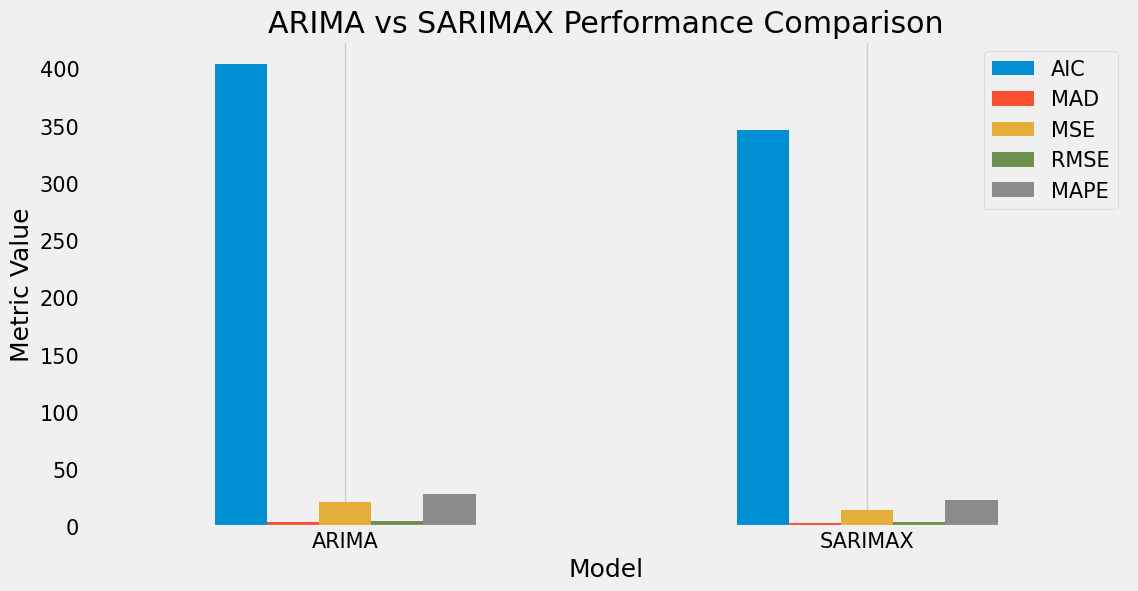

In [152]:
comparison.set_index('Model')[
    ['AIC', 'MAD', 'MSE', 'RMSE', 'MAPE']
].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('ARIMA vs SARIMAX Performance Comparison')
plt.ylabel('Metric Value')
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y')

plt.show()